In [1]:
# ============================================================
# CELL 0. Imports and file loading
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ----------------------------
# File path
# ----------------------------
DATA_DIR = Path(r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data")
FILE_NAME = "RV_For_RF4_Index_2.csv"
FILE_PATH = DATA_DIR / FILE_NAME

# Output directory
OUT_DIR = DATA_DIR / "ELE_analysis_outputs"
OUT_DIR.mkdir(exist_ok=True)

# ----------------------------
# Load data
# sep=None tries to infer delimiter; useful if the .csv is actually tab-separated
# ----------------------------
df = pd.read_csv(FILE_PATH, sep=None, engine="python")

# Clean column names: strip leading/trailing spaces
df.columns = df.columns.str.strip()

print("Loaded file:", FILE_PATH)
print("Shape:", df.shape)
print("\nAvailable columns:")
for c in df.columns:
    print("-", c)

# ----------------------------
# Define core columns
# ----------------------------
FLW_COL = "Dead_Wood"             # floodplain large wood
CLW_COL = "LW_Presence"           # in-channel large wood
ELE_COL = "ELE (EffectLatExp)"    # effective lateral exposure

# Optional diagnostic columns
VALLEY_COL = "ValleyConfinIndex"
LAT_COL = "Lat_Connectivity"

# Other potentially relevant predictors
OPTIONAL_PREDICTORS = [
    "ValleyConfinIndex",
    "Lat_Connectivity",
    "SPI / Width",
    "Gradient (%)",
    "Sinuosity",
    "Width_Mean",
    "Basal_Area (m2/ha)",
    "StructuralIndex",
    "P50_Height",
    "Height_IQR",
    "Distance to outlet (km)"
]

# Check required columns
required = [FLW_COL, CLW_COL, ELE_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Convert core columns to numeric
for c in [FLW_COL, CLW_COL, ELE_COL, VALLEY_COL, LAT_COL] + OPTIONAL_PREDICTORS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows without core variables
df_core = df.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()

# Ensure ordinal classes are integer
df_core[FLW_COL] = df_core[FLW_COL].astype(int)
df_core[CLW_COL] = df_core[CLW_COL].astype(int)

print("\nCore data shape after dropping missing FLW/CLW/ELE:", df_core.shape)
print(df_core[[FLW_COL, CLW_COL, ELE_COL]].head())

Loaded file: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index_2.csv
Shape: (88, 25)

Available columns:
- Id_RipUnit
- Id_Reach
- Basin
- Sub_Basin
- Reach
- Bank
- RipUnit
- Lentgh (m)
- LW_Presence
- Dead_Wood
- Standing_Dead_Trees
- Sinuosity
- Lat_Connectivity
- Gradient (%)
- SPI / Width
- Distance to outlet (km)
- Regeneration
- Width_Mean
- Basal_Area (m2/ha)
- P50_Height
- Height_IQR
- Invasive_Ab
- StructuralIndex
- ValleyConfinIndex
- ELE (EffectLatExp)

Core data shape after dropping missing FLW/CLW/ELE: (88, 25)
   Dead_Wood  LW_Presence  ELE (EffectLatExp)
0          2            2            6.286780
1          3            2           12.086567
2          1            1            4.096068
3          1            1            4.289503
4          2            3            1.989345



Descriptive statistics:


,n,min,Q1,median,mean,Q3,max,std
ELE (EffectLatExp),88.0,1.0263,2.656321,4.682218,5.004785,6.332989,12.086567,2.914646
ValleyConfinIndex,88.0,1.0263,2.657284,4.947749,5.615855,8.516091,17.158012,3.565307
Lat_Connectivity,88.0,1.0000,4.000000,4.000000,3.750000,4.000000,4.000000,0.647719
LatConnectWeight,88.0,0.2500,1.000000,1.000000,0.937500,1.000000,1.000000,0.161930



Lat_Connectivity distribution:


,count,percent
Lat_Connectivity,,
1,2,2.27
2,4,4.55
3,8,9.09
4,74,84.09



Cases with Lat_Connectivity < 4: 14 (15.91%)

Spearman correlations: ELE and ValleyConfinIndex versus selected variables


,Predictor,rho_ELE,p_ELE,n_ELE,rho_ValleyConfinIndex,p_ValleyConfinIndex,n_ValleyConfinIndex,difference_abs_rho
0,ValleyConfinIndex,0.933673,4.071538e-40,88,1.000000,0.000000e+00,88,-0.066327
1,Lat_Connectivity,-0.028741,7.903811e-01,88,-0.295109,5.250706e-03,88,-0.266368
2,LatConnectWeight,-0.028741,7.903811e-01,88,-0.295109,5.250706e-03,88,-0.266368
3,SPI / Width,-0.054258,6.156135e-01,88,0.009745,9.281994e-01,88,0.044513
4,Gradient (%),-0.018744,8.623894e-01,88,0.008879,9.345675e-01,88,0.009865
5,Sinuosity,-0.339103,1.229638e-03,88,-0.421308,4.357002e-05,88,-0.082204
6,Width_Mean,-0.268921,1.129323e-02,88,-0.312010,3.083272e-03,88,-0.043088
7,Basal_Area (m2/ha),-0.004790,9.646689e-01,88,-0.143553,1.821015e-01,88,-0.138762
8,StructuralIndex,0.013835,8.982032e-01,88,0.061151,5.714108e-01,88,-0.047316
9,P50_Height,-0.253600,1.712209e-02,88,-0.330456,1.663882e-03,88,-0.076857



ELE vs ValleyConfinIndex: Spearman rho = 0.934, p = 4.072e-40, n = 88


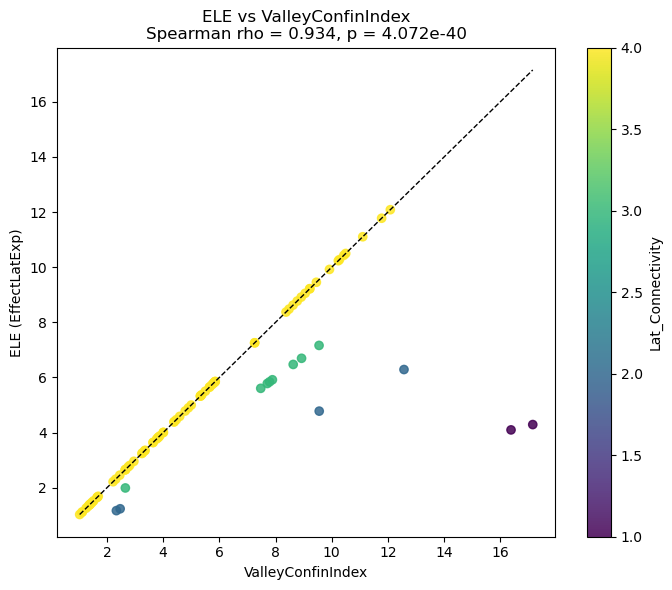

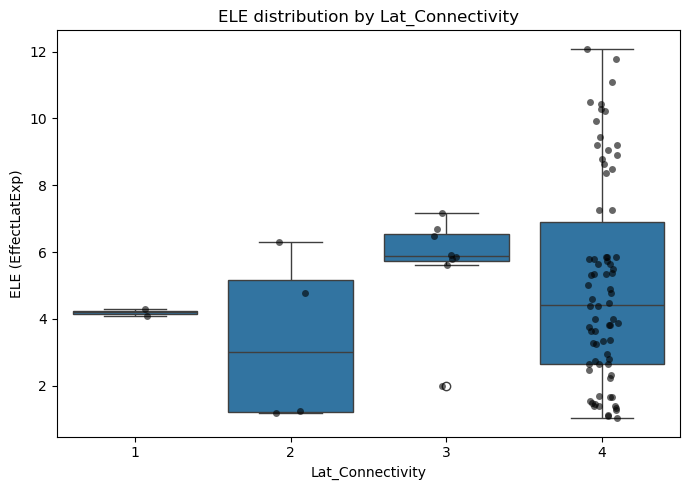


PRELIMINARY INTERPRETATION
ELE is very strongly correlated with ValleyConfinIndex (rho=0.934, p=4.072e-40). This indicates that ELE is mostly dominated by the natural valley-confinement component.
14 cases (15.9%) have Lat_Connectivity < 4. Therefore, the artificial lateral exposure component modifies only a minority of observations.
Interpret ELE cautiously as a contextual or sensitivity descriptor, not as a direct measure of hydraulic connectivity or observed wood recruitment.


In [3]:
# ============================================================
# CELL 1. Descriptive statistics and diagnostics:
# Is ELE measuring something different?
# Corrected version
# ============================================================

def descriptive_stats(series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "min": x.min(),
        "Q1": x.quantile(0.25),
        "median": x.median(),
        "mean": x.mean(),
        "Q3": x.quantile(0.75),
        "max": x.max(),
        "std": x.std()
    })

# ------------------------------------------------------------
# Create explicit lateral weighting variable if Lat_Connectivity is 1–4
# ------------------------------------------------------------
if LAT_COL in df_core.columns:
    df_core["LatConnectWeight"] = df_core[LAT_COL] / 4.0
    LAT_WEIGHT_COL = "LatConnectWeight"
else:
    LAT_WEIGHT_COL = None

# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------
desc_vars = [ELE_COL]

if VALLEY_COL in df_core.columns:
    desc_vars.append(VALLEY_COL)

if LAT_COL in df_core.columns:
    desc_vars.append(LAT_COL)

if LAT_WEIGHT_COL is not None:
    desc_vars.append(LAT_WEIGHT_COL)

desc_table = pd.DataFrame({
    v: descriptive_stats(df_core[v]) for v in desc_vars
}).T

print("\nDescriptive statistics:")
display(desc_table)

desc_table.to_csv(OUT_DIR / "ELE_descriptive_statistics.csv", index=True)

# ------------------------------------------------------------
# Distribution of Lat_Connectivity and LatConnectWeight
# ------------------------------------------------------------
if LAT_COL in df_core.columns:
    lat_counts = df_core[LAT_COL].value_counts(dropna=False).sort_index()
    lat_pct = df_core[LAT_COL].value_counts(normalize=True, dropna=False).sort_index() * 100

    lat_table = pd.DataFrame({
        "count": lat_counts,
        "percent": lat_pct.round(2)
    })

    print("\nLat_Connectivity distribution:")
    display(lat_table)

    n_less_4 = (df_core[LAT_COL] < 4).sum()
    pct_less_4 = 100 * n_less_4 / df_core[LAT_COL].notna().sum()

    print(f"\nCases with Lat_Connectivity < 4: {n_less_4} ({pct_less_4:.2f}%)")

    lat_table.to_csv(OUT_DIR / "LatConnectivity_distribution.csv", index=True)

# ------------------------------------------------------------
# Robust Spearman function
# ------------------------------------------------------------
def spearman_pair(data, x_col, y_col):
    """
    Robust Spearman correlation between two columns.
    Handles the case x_col == y_col explicitly.
    """

    if x_col not in data.columns or y_col not in data.columns:
        return np.nan, np.nan, 0

    tmp = data[[x_col, y_col]].copy()

    # If x_col == y_col, pandas creates duplicate columns.
    # Handle this case before dropna/nunique.
    if x_col == y_col:
        x = pd.to_numeric(data[x_col], errors="coerce").dropna()
        if x.size < 3 or x.nunique() < 2:
            return np.nan, np.nan, x.size
        return 1.0, 0.0, x.size

    x = pd.to_numeric(tmp[x_col], errors="coerce")
    y = pd.to_numeric(tmp[y_col], errors="coerce")

    tmp2 = pd.DataFrame({"x": x, "y": y}).dropna()

    if tmp2.shape[0] < 3:
        return np.nan, np.nan, tmp2.shape[0]

    if tmp2["x"].nunique() < 2 or tmp2["y"].nunique() < 2:
        return np.nan, np.nan, tmp2.shape[0]

    rho, p = stats.spearmanr(tmp2["x"], tmp2["y"])
    return rho, p, tmp2.shape[0]

# ------------------------------------------------------------
# Variables to compare against ELE
# ------------------------------------------------------------
candidate_predictors = [
    VALLEY_COL,
    LAT_COL,
    LAT_WEIGHT_COL,
    "SPI / Width",
    "Gradient (%)",
    "Sinuosity",
    "Width_Mean",
    "Basal_Area (m2/ha)",
    "StructuralIndex",
    "P50_Height",
    "Height_IQR",
    "Distance to outlet (km)"
]

# Keep only valid columns, remove None, remove duplicates, remove ELE itself
predictors = []
for p in candidate_predictors:
    if p is not None and p in df_core.columns and p != ELE_COL and p not in predictors:
        predictors.append(p)

# ------------------------------------------------------------
# Spearman correlations:
# ELE versus predictors, and ValleyConfinIndex versus predictors
# ------------------------------------------------------------
rows = []

for pred in predictors:
    rho_ele, p_ele, n_ele = spearman_pair(df_core, ELE_COL, pred)

    if VALLEY_COL in df_core.columns:
        rho_val, p_val, n_val = spearman_pair(df_core, VALLEY_COL, pred)
    else:
        rho_val, p_val, n_val = np.nan, np.nan, np.nan

    if pd.notna(rho_ele) and pd.notna(rho_val):
        diff_abs = abs(rho_ele) - abs(rho_val)
    else:
        diff_abs = np.nan

    rows.append({
        "Predictor": pred,
        "rho_ELE": rho_ele,
        "p_ELE": p_ele,
        "n_ELE": n_ele,
        "rho_ValleyConfinIndex": rho_val,
        "p_ValleyConfinIndex": p_val,
        "n_ValleyConfinIndex": n_val,
        "difference_abs_rho": diff_abs
    })

corr_table = pd.DataFrame(rows)

print("\nSpearman correlations: ELE and ValleyConfinIndex versus selected variables")
display(corr_table)

corr_table.to_csv(OUT_DIR / "ELE_vs_other_variables_spearman.csv", index=False)

# ------------------------------------------------------------
# Specific ELE vs ValleyConfinIndex diagnostic
# ------------------------------------------------------------
if VALLEY_COL in df_core.columns:
    rho_ev, p_ev, n_ev = spearman_pair(df_core, ELE_COL, VALLEY_COL)
    print(f"\nELE vs ValleyConfinIndex: Spearman rho = {rho_ev:.3f}, p = {p_ev:.4g}, n = {n_ev}")

    plt.figure(figsize=(7, 6))

    if LAT_COL in df_core.columns:
        sc = plt.scatter(
            df_core[VALLEY_COL],
            df_core[ELE_COL],
            c=df_core[LAT_COL],
            alpha=0.85
        )
        cbar = plt.colorbar(sc)
        cbar.set_label("Lat_Connectivity")
    else:
        plt.scatter(
            df_core[VALLEY_COL],
            df_core[ELE_COL],
            alpha=0.85
        )

    min_val = np.nanmin([df_core[VALLEY_COL].min(), df_core[ELE_COL].min()])
    max_val = np.nanmax([df_core[VALLEY_COL].max(), df_core[ELE_COL].max()])

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1,
        color="black"
    )

    plt.xlabel("ValleyConfinIndex")
    plt.ylabel("ELE (EffectLatExp)")
    plt.title(f"ELE vs ValleyConfinIndex\nSpearman rho = {rho_ev:.3f}, p = {p_ev:.4g}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "ELE_vs_ValleyConfinIndex.png", dpi=300)
    plt.show()

# ------------------------------------------------------------
# ELE by Lat_Connectivity
# ------------------------------------------------------------
if LAT_COL in df_core.columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df_core, x=LAT_COL, y=ELE_COL)
    sns.stripplot(
        data=df_core,
        x=LAT_COL,
        y=ELE_COL,
        color="black",
        alpha=0.6,
        jitter=True
    )

    plt.xlabel("Lat_Connectivity")
    plt.ylabel("ELE (EffectLatExp)")
    plt.title("ELE distribution by Lat_Connectivity")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "ELE_by_LatConnectivity.png", dpi=300)
    plt.show()

# ------------------------------------------------------------
# Brief automatic interpretation
# ------------------------------------------------------------
print("\n====================")
print("PRELIMINARY INTERPRETATION")
print("====================")

if VALLEY_COL in df_core.columns:
    rho_ev, p_ev, n_ev = spearman_pair(df_core, ELE_COL, VALLEY_COL)

    if abs(rho_ev) > 0.90:
        print(
            f"ELE is very strongly correlated with ValleyConfinIndex "
            f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
            "This indicates that ELE is mostly dominated by the natural valley-confinement component."
        )
    elif abs(rho_ev) > 0.70:
        print(
            f"ELE is strongly correlated with ValleyConfinIndex "
            f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
            "This suggests substantial redundancy between both variables."
        )
    else:
        print(
            f"ELE is not strongly correlated with ValleyConfinIndex "
            f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
            "The artificial weighting appears to modify the natural confinement signal."
        )

if LAT_COL in df_core.columns:
    n_modified = (df_core[LAT_COL] < 4).sum()
    pct_modified = 100 * n_modified / df_core[LAT_COL].notna().sum()

    print(
        f"{n_modified} cases ({pct_modified:.1f}%) have Lat_Connectivity < 4. "
        "Therefore, the artificial lateral exposure component modifies only a minority of observations."
    )

print(
    "Interpret ELE cautiously as a contextual or sensitivity descriptor, "
    "not as a direct measure of hydraulic connectivity or observed wood recruitment."
)


Descriptive statistics:


,n,min,Q1,median,mean,Q3,max,std
ELE (EffectLatExp),88.0,1.0263,2.656321,4.682218,5.004785,6.332989,12.086567,2.914646
ValleyConfinIndex,88.0,1.0263,2.657284,4.947749,5.615855,8.516091,17.158012,3.565307
Lat_Connectivity,88.0,1.0000,4.000000,4.000000,3.750000,4.000000,4.000000,0.647719
LatConnectWeight,88.0,0.2500,1.000000,1.000000,0.937500,1.000000,1.000000,0.161930



Lat_Connectivity distribution:


,count,percent
Lat_Connectivity,,
1,2,2.27
2,4,4.55
3,8,9.09
4,74,84.09



Cases with Lat_Connectivity < 4: 14 (15.91%)

Direct diagnostic:
ELE vs ValleyConfinIndex: rho = 0.934, p = 4.072e-40, n = 88

Spearman correlations: ELE and ValleyConfinIndex versus selected variables


,Predictor,rho_ELE,p_ELE,n_ELE,rho_ValleyConfinIndex,p_ValleyConfinIndex,n_ValleyConfinIndex,difference_abs_rho
0,Lat_Connectivity,-0.028741,0.790381,88,-0.295109,5.250706e-03,88,-0.266368
1,LatConnectWeight,-0.028741,0.790381,88,-0.295109,5.250706e-03,88,-0.266368
2,SPI / Width,-0.054258,0.615614,88,0.009745,9.281994e-01,88,0.044513
3,Gradient (%),-0.018744,0.862389,88,0.008879,9.345675e-01,88,0.009865
4,Sinuosity,-0.339103,0.001230,88,-0.421308,4.357002e-05,88,-0.082204
5,Width_Mean,-0.268921,0.011293,88,-0.312010,3.083272e-03,88,-0.043088
6,Basal_Area (m2/ha),-0.004790,0.964669,88,-0.143553,1.821015e-01,88,-0.138762
7,StructuralIndex,0.013835,0.898203,88,0.061151,5.714108e-01,88,-0.047316
8,P50_Height,-0.253600,0.017122,88,-0.330456,1.663882e-03,88,-0.076857
9,Height_IQR,0.124865,0.246404,88,0.049912,6.442156e-01,88,0.074952


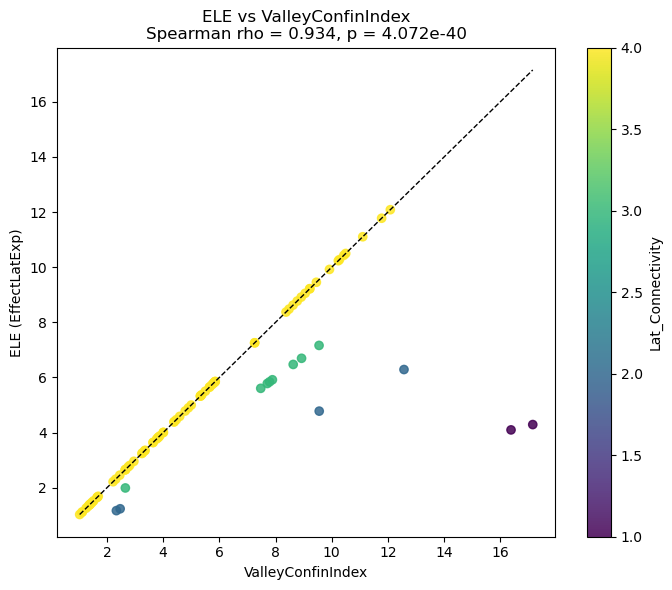

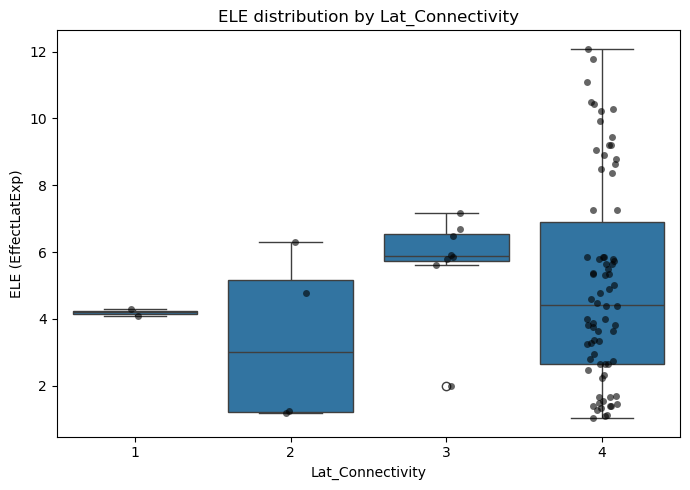


PRELIMINARY INTERPRETATION
ELE is very strongly correlated with ValleyConfinIndex (rho=0.934, p=4.072e-40). This indicates that ELE is mostly dominated by the natural valley-confinement component.
14 cases (15.9%) have Lat_Connectivity < 4. Therefore, the artificial lateral exposure component modifies only a minority of observations.
ELE should therefore be interpreted cautiously as a contextual or sensitivity descriptor, not as a direct measure of hydraulic connectivity, floodplain inundation frequency, or observed wood recruitment.


In [5]:
# ============================================================
# CELL 1 FIXED. ELE diagnostic without duplicate-column error
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------
FLW_COL = "Dead_Wood"
CLW_COL = "LW_Presence"
ELE_COL = "ELE (EffectLatExp)"
VALLEY_COL = "ValleyConfinIndex"
LAT_COL = "Lat_Connectivity"

# Safety copy
df_ele = df_core.copy()

# Ensure numeric
for c in [FLW_COL, CLW_COL, ELE_COL, VALLEY_COL, LAT_COL,
          "SPI / Width", "Gradient (%)", "Sinuosity", "Width_Mean",
          "Basal_Area (m2/ha)", "StructuralIndex", "P50_Height",
          "Height_IQR", "Distance to outlet (km)"]:
    if c in df_ele.columns:
        df_ele[c] = pd.to_numeric(df_ele[c], errors="coerce")

# Create real weighting factor
# Lat_Connectivity is 1–4, whereas the actual weighting used in ELE is 0.25–1
if LAT_COL in df_ele.columns:
    df_ele["LatConnectWeight"] = df_ele[LAT_COL] / 4.0
    LAT_WEIGHT_COL = "LatConnectWeight"
else:
    LAT_WEIGHT_COL = None

# ------------------------------------------------------------
# Descriptive statistics
# ------------------------------------------------------------
def descriptive_stats(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return pd.Series({
        "n": x.size,
        "min": x.min(),
        "Q1": x.quantile(0.25),
        "median": x.median(),
        "mean": x.mean(),
        "Q3": x.quantile(0.75),
        "max": x.max(),
        "std": x.std()
    })

desc_vars = [ELE_COL]

if VALLEY_COL in df_ele.columns:
    desc_vars.append(VALLEY_COL)

if LAT_COL in df_ele.columns:
    desc_vars.append(LAT_COL)

if LAT_WEIGHT_COL is not None:
    desc_vars.append(LAT_WEIGHT_COL)

desc_table = pd.DataFrame({v: descriptive_stats(df_ele[v]) for v in desc_vars}).T

print("\nDescriptive statistics:")
display(desc_table)

desc_table.to_csv(OUT_DIR / "ELE_descriptive_statistics.csv")

# ------------------------------------------------------------
# Lat_Connectivity distribution
# ------------------------------------------------------------
if LAT_COL in df_ele.columns:
    lat_table = pd.DataFrame({
        "count": df_ele[LAT_COL].value_counts(dropna=False).sort_index(),
        "percent": (df_ele[LAT_COL].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2)
    })

    print("\nLat_Connectivity distribution:")
    display(lat_table)

    n_less_4 = int((df_ele[LAT_COL] < 4).sum())
    pct_less_4 = 100 * n_less_4 / df_ele[LAT_COL].notna().sum()

    print(f"\nCases with Lat_Connectivity < 4: {n_less_4} ({pct_less_4:.2f}%)")

    lat_table.to_csv(OUT_DIR / "LatConnectivity_distribution.csv")

# ------------------------------------------------------------
# Robust Spearman function
# ------------------------------------------------------------
def spearman_pair(data, x_col, y_col):
    """
    Spearman correlation between two different columns.
    This function avoids duplicate-column problems.
    """

    if x_col not in data.columns or y_col not in data.columns:
        return np.nan, np.nan, 0

    x = pd.to_numeric(data[x_col], errors="coerce")
    y = pd.to_numeric(data[y_col], errors="coerce")

    tmp = pd.DataFrame({"x": x, "y": y}).dropna()

    if tmp.shape[0] < 3:
        return np.nan, np.nan, tmp.shape[0]

    if tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
        return np.nan, np.nan, tmp.shape[0]

    rho, p = stats.spearmanr(tmp["x"], tmp["y"])
    return rho, p, tmp.shape[0]

# ------------------------------------------------------------
# Direct diagnostic: ELE vs ValleyConfinIndex
# ------------------------------------------------------------
rho_ev, p_ev, n_ev = spearman_pair(df_ele, ELE_COL, VALLEY_COL)

print("\nDirect diagnostic:")
print(f"ELE vs ValleyConfinIndex: rho = {rho_ev:.3f}, p = {p_ev:.4g}, n = {n_ev}")

# ------------------------------------------------------------
# Correlations with other variables
# IMPORTANT: ValleyConfinIndex is NOT included as a predictor here,
# because it is tested separately above.
# ------------------------------------------------------------
candidate_predictors = [
    LAT_COL,
    LAT_WEIGHT_COL,
    "SPI / Width",
    "Gradient (%)",
    "Sinuosity",
    "Width_Mean",
    "Basal_Area (m2/ha)",
    "StructuralIndex",
    "P50_Height",
    "Height_IQR",
    "Distance to outlet (km)"
]

# Clean list: remove None, missing columns, duplicates
predictors = []
for p in candidate_predictors:
    if p is not None and p in df_ele.columns and p not in predictors:
        predictors.append(p)

rows = []

for pred in predictors:
    rho_ele, p_ele, n_ele = spearman_pair(df_ele, ELE_COL, pred)
    rho_val, p_val, n_val = spearman_pair(df_ele, VALLEY_COL, pred)

    rows.append({
        "Predictor": pred,
        "rho_ELE": rho_ele,
        "p_ELE": p_ele,
        "n_ELE": n_ele,
        "rho_ValleyConfinIndex": rho_val,
        "p_ValleyConfinIndex": p_val,
        "n_ValleyConfinIndex": n_val,
        "difference_abs_rho": abs(rho_ele) - abs(rho_val)
        if pd.notna(rho_ele) and pd.notna(rho_val) else np.nan
    })

corr_table = pd.DataFrame(rows)

print("\nSpearman correlations: ELE and ValleyConfinIndex versus selected variables")
display(corr_table)

corr_table.to_csv(OUT_DIR / "ELE_vs_other_variables_spearman.csv", index=False)

# ------------------------------------------------------------
# Plot 1. ELE vs ValleyConfinIndex
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

sc = plt.scatter(
    df_ele[VALLEY_COL],
    df_ele[ELE_COL],
    c=df_ele[LAT_COL] if LAT_COL in df_ele.columns else None,
    alpha=0.85
)

if LAT_COL in df_ele.columns:
    cbar = plt.colorbar(sc)
    cbar.set_label("Lat_Connectivity")

min_val = np.nanmin([df_ele[VALLEY_COL].min(), df_ele[ELE_COL].min()])
max_val = np.nanmax([df_ele[VALLEY_COL].max(), df_ele[ELE_COL].max()])

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
    color="black"
)

plt.xlabel("ValleyConfinIndex")
plt.ylabel("ELE (EffectLatExp)")
plt.title(f"ELE vs ValleyConfinIndex\nSpearman rho = {rho_ev:.3f}, p = {p_ev:.4g}")
plt.tight_layout()
plt.savefig(OUT_DIR / "ELE_vs_ValleyConfinIndex.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Plot 2. ELE by Lat_Connectivity
# ------------------------------------------------------------
if LAT_COL in df_ele.columns:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df_ele,
        x=LAT_COL,
        y=ELE_COL
    )

    sns.stripplot(
        data=df_ele,
        x=LAT_COL,
        y=ELE_COL,
        color="black",
        alpha=0.6,
        jitter=True
    )

    plt.xlabel("Lat_Connectivity")
    plt.ylabel("ELE (EffectLatExp)")
    plt.title("ELE distribution by Lat_Connectivity")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "ELE_by_LatConnectivity.png", dpi=300)
    plt.show()

# ------------------------------------------------------------
# Short automatic interpretation
# ------------------------------------------------------------
print("\n====================")
print("PRELIMINARY INTERPRETATION")
print("====================")

if abs(rho_ev) > 0.90:
    print(
        f"ELE is very strongly correlated with ValleyConfinIndex "
        f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
        "This indicates that ELE is mostly dominated by the natural valley-confinement component."
    )
elif abs(rho_ev) > 0.70:
    print(
        f"ELE is strongly correlated with ValleyConfinIndex "
        f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
        "This suggests substantial redundancy between both variables."
    )
else:
    print(
        f"ELE is not strongly correlated with ValleyConfinIndex "
        f"(rho={rho_ev:.3f}, p={p_ev:.4g}). "
        "The artificial weighting appears to modify the natural confinement signal."
    )

if LAT_COL in df_ele.columns:
    n_modified = int((df_ele[LAT_COL] < 4).sum())
    pct_modified = 100 * n_modified / df_ele[LAT_COL].notna().sum()

    print(
        f"{n_modified} cases ({pct_modified:.1f}%) have Lat_Connectivity < 4. "
        "Therefore, the artificial lateral exposure component modifies only a minority of observations."
    )

print(
    "ELE should therefore be interpreted cautiously as a contextual or sensitivity descriptor, "
    "not as a direct measure of hydraulic connectivity, floodplain inundation frequency, "
    "or observed wood recruitment."
)


Bivariate relationships with ELE:


,response,predictor,n,spearman_rho,spearman_p,kruskal_H,kruskal_p
0,Dead_Wood,ELE (EffectLatExp),88,-0.131599,0.221638,2.167743,0.538330
1,LW_Presence,ELE (EffectLatExp),88,-0.008741,0.935583,2.104822,0.550938


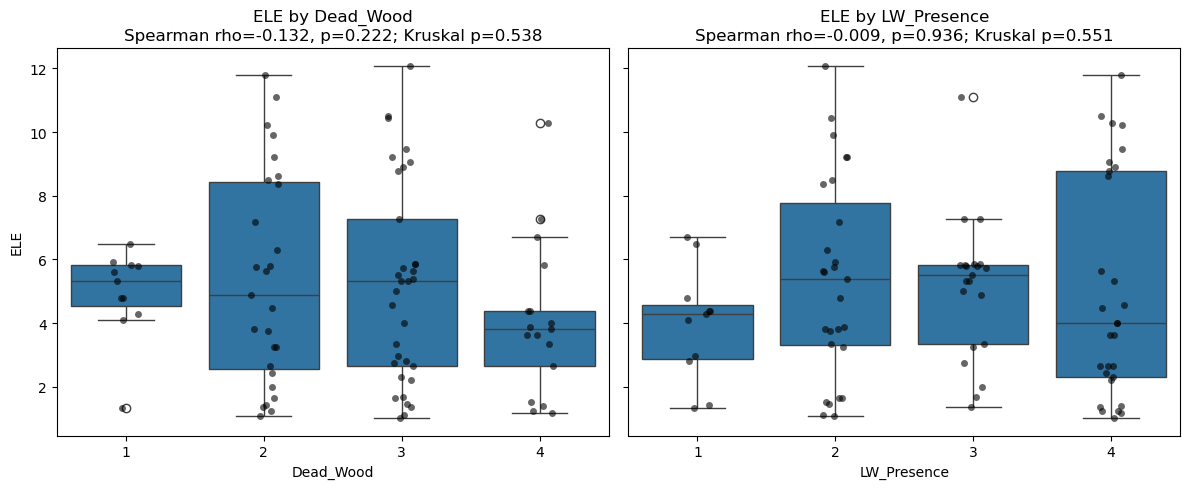

In [6]:
# ============================================================
# CELL 2. Direct bivariate relationships:
# FLW ~ ELE and CLW ~ ELE
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Safety: use df_ele if available; otherwise use df_core
try:
    data = df_ele.copy()
except NameError:
    data = df_core.copy()

FLW_COL = "Dead_Wood"
CLW_COL = "LW_Presence"
ELE_COL = "ELE (EffectLatExp)"

# Ensure numeric
for c in [FLW_COL, CLW_COL, ELE_COL]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

data = data.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()
data[FLW_COL] = data[FLW_COL].astype(int)
data[CLW_COL] = data[CLW_COL].astype(int)

def spearman_and_kruskal(data, response_col, predictor_col):
    tmp = data[[response_col, predictor_col]].dropna().copy()

    if tmp.shape[0] < 3 or tmp[response_col].nunique() < 2 or tmp[predictor_col].nunique() < 2:
        return {
            "response": response_col,
            "predictor": predictor_col,
            "n": tmp.shape[0],
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "kruskal_H": np.nan,
            "kruskal_p": np.nan
        }

    rho, p_spear = stats.spearmanr(tmp[response_col], tmp[predictor_col])

    groups = [
        g[predictor_col].dropna().values
        for _, g in tmp.groupby(response_col)
        if len(g[predictor_col].dropna()) > 0
    ]

    if len(groups) >= 2:
        h, p_kw = stats.kruskal(*groups)
    else:
        h, p_kw = np.nan, np.nan

    return {
        "response": response_col,
        "predictor": predictor_col,
        "n": tmp.shape[0],
        "spearman_rho": rho,
        "spearman_p": p_spear,
        "kruskal_H": h,
        "kruskal_p": p_kw
    }

biv_results = pd.DataFrame([
    spearman_and_kruskal(data, FLW_COL, ELE_COL),
    spearman_and_kruskal(data, CLW_COL, ELE_COL)
])

print("\nBivariate relationships with ELE:")
display(biv_results)

biv_results.to_csv(OUT_DIR / "Bivariate_FLW_CLW_with_ELE.csv", index=False)

# ------------------------------------------------------------
# Boxplots of ELE by FLW and CLW classes
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, response in zip(axes, [FLW_COL, CLW_COL]):
    sns.boxplot(
        data=data,
        x=response,
        y=ELE_COL,
        ax=ax
    )

    sns.stripplot(
        data=data,
        x=response,
        y=ELE_COL,
        color="black",
        alpha=0.6,
        jitter=True,
        ax=ax
    )

    res = biv_results[biv_results["response"] == response].iloc[0]

    ax.set_title(
        f"ELE by {response}\n"
        f"Spearman rho={res['spearman_rho']:.3f}, p={res['spearman_p']:.3g}; "
        f"Kruskal p={res['kruskal_p']:.3g}"
    )
    ax.set_xlabel(response)
    ax.set_ylabel("ELE")

plt.tight_layout()
plt.savefig(OUT_DIR / "Boxplots_ELE_by_FLW_CLW.png", dpi=300)
plt.show()

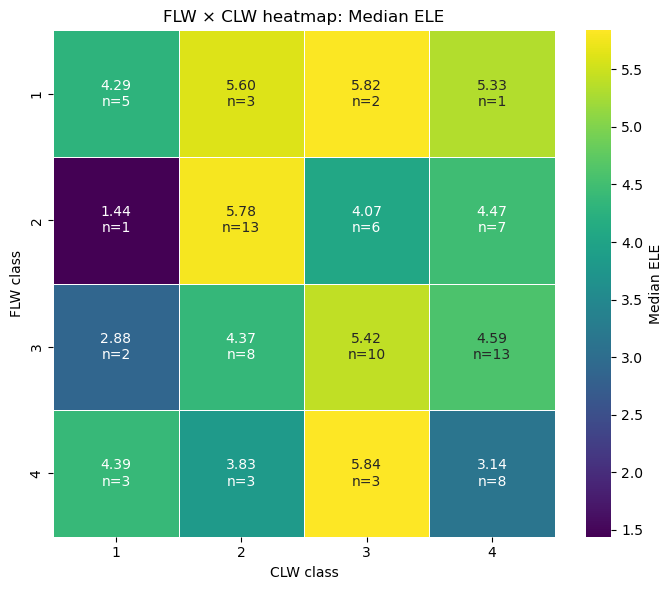

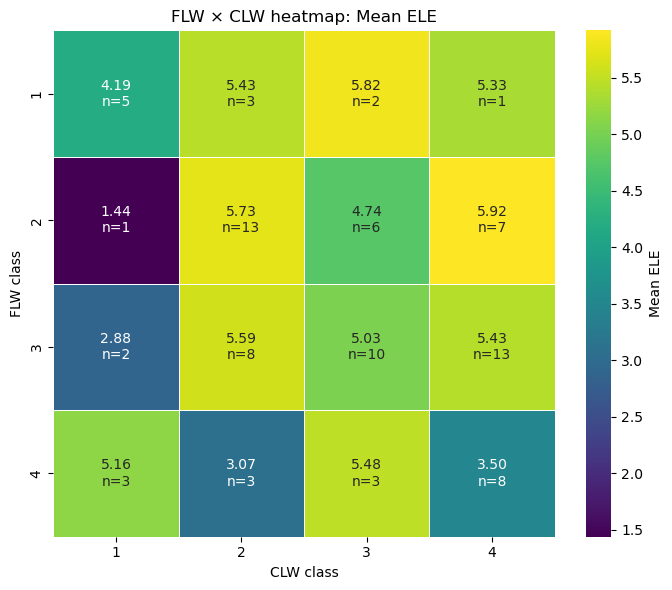


FLW × CLW summary table with ELE:


,Dead_Wood,LW_Presence,n,median_ELE,mean_ELE,min_ELE,max_ELE
0,1,1,5,4.289503,4.192006,1.325273,6.471613
1,1,2,3,5.604644,5.433905,4.781336,5.915735
2,1,3,2,5.815339,5.815339,5.789993,5.840685
3,1,4,1,5.330448,5.330448,5.330448,5.330448
4,2,1,1,1.439954,1.439954,1.439954,1.439954
5,2,2,13,5.779830,5.727972,1.099836,9.919900
6,2,3,6,4.068708,4.736019,1.380126,11.105095
7,2,4,7,4.465965,5.919847,1.233776,11.777632
8,3,1,2,2.881832,2.881832,2.807751,2.955913
9,3,2,8,4.365765,5.590234,1.124750,12.086567



Interpretation aid:
Use this heatmap only as an exploratory visualization. Cells with n < 3 should not be interpreted as robust evidence.
Median ELE in FLW high + CLW high cells: 5.00
Median ELE in other cells: 4.38


In [9]:
# ============================================================
# CELL 3. Heatmap FLW x CLW with median and mean ELE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    data = df_ele.copy()
except NameError:
    data = df_core.copy()

FLW_COL = "Dead_Wood"
CLW_COL = "LW_Presence"
ELE_COL = "ELE (EffectLatExp)"

for c in [FLW_COL, CLW_COL, ELE_COL]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

data = data.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()
data[FLW_COL] = data[FLW_COL].astype(int)
data[CLW_COL] = data[CLW_COL].astype(int)

classes = [1, 2, 3, 4]

def make_flw_clw_ele_heatmap(data, aggfunc="median", output_name="heatmap.png"):
    """
    Heatmap:
    rows = FLW classes
    columns = CLW classes
    cell colour = median or mean ELE
    annotation = value + n
    """

    if aggfunc not in ["median", "mean"]:
        raise ValueError("aggfunc must be 'median' or 'mean'.")

    value_table = data.pivot_table(
        index=FLW_COL,
        columns=CLW_COL,
        values=ELE_COL,
        aggfunc=aggfunc
    ).reindex(index=classes, columns=classes)

    count_table = data.pivot_table(
        index=FLW_COL,
        columns=CLW_COL,
        values=ELE_COL,
        aggfunc="count"
    ).reindex(index=classes, columns=classes)

    annot = value_table.copy().astype(object)

    for i in classes:
        for j in classes:
            val = value_table.loc[i, j]
            n = count_table.loc[i, j]

            if pd.isna(val) or pd.isna(n):
                annot.loc[i, j] = ""
            else:
                annot.loc[i, j] = f"{val:.2f}\nn={int(n)}"

    label = f"{aggfunc.capitalize()} ELE"

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        value_table,
        annot=annot,
        fmt="",
        cmap="viridis",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": label}
    )

    plt.xlabel("CLW class")
    plt.ylabel("FLW class")
    plt.title(f"FLW × CLW heatmap: {label}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=300)
    plt.show()

    return value_table, count_table

median_table, n_table = make_flw_clw_ele_heatmap(
    data,
    aggfunc="median",
    output_name="Heatmap_FLW_CLW_median_ELE.png"
)

mean_table, _ = make_flw_clw_ele_heatmap(
    data,
    aggfunc="mean",
    output_name="Heatmap_FLW_CLW_mean_ELE.png"
)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------
summary_table = (
    data
    .groupby([FLW_COL, CLW_COL])[ELE_COL]
    .agg(
        n="count",
        median_ELE="median",
        mean_ELE="mean",
        min_ELE="min",
        max_ELE="max"
    )
    .reset_index()
)

print("\nFLW × CLW summary table with ELE:")
display(summary_table)

summary_table.to_csv(OUT_DIR / "FLW_CLW_ELE_summary_table.csv", index=False)

# ------------------------------------------------------------
# Short interpretation aid
# ------------------------------------------------------------
print("\nInterpretation aid:")
print(
    "Use this heatmap only as an exploratory visualization. "
    "Cells with n < 3 should not be interpreted as robust evidence."
)

high_high = summary_table[(summary_table[FLW_COL] >= 3) & (summary_table[CLW_COL] >= 3)]
low_or_mixed = summary_table[~((summary_table[FLW_COL] >= 3) & (summary_table[CLW_COL] >= 3))]

if len(high_high) > 0 and len(low_or_mixed) > 0:
    print(f"Median ELE in FLW high + CLW high cells: {high_high['median_ELE'].median():.2f}")
    print(f"Median ELE in other cells: {low_or_mixed['median_ELE'].median():.2f}")


ELE tertile distribution:


ELE_tertile
Low ELE       29
Medium ELE    29
High ELE      30
Name: count, dtype: int64


ELE tertile thresholds:


,ELE_tertile,n,min_ELE,median_ELE,max_ELE
0,Low ELE,29,1.026300,1.653956,3.337846
1,Medium ELE,29,3.355415,4.586865,5.779830
2,High ELE,30,5.789993,8.552048,12.086567


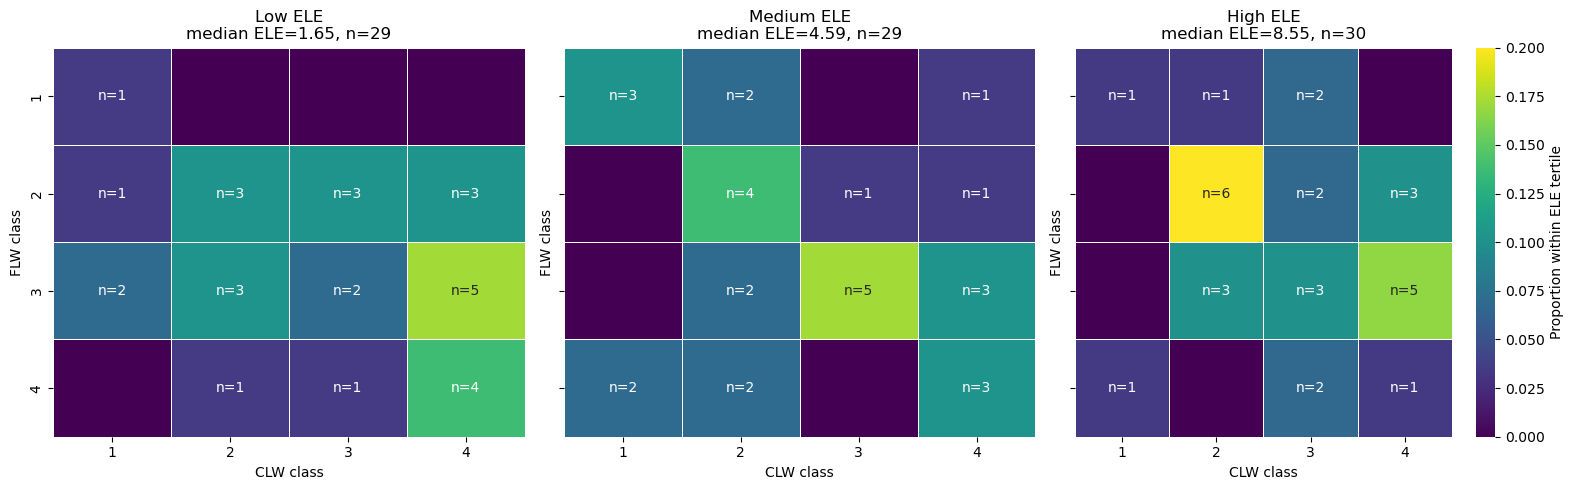

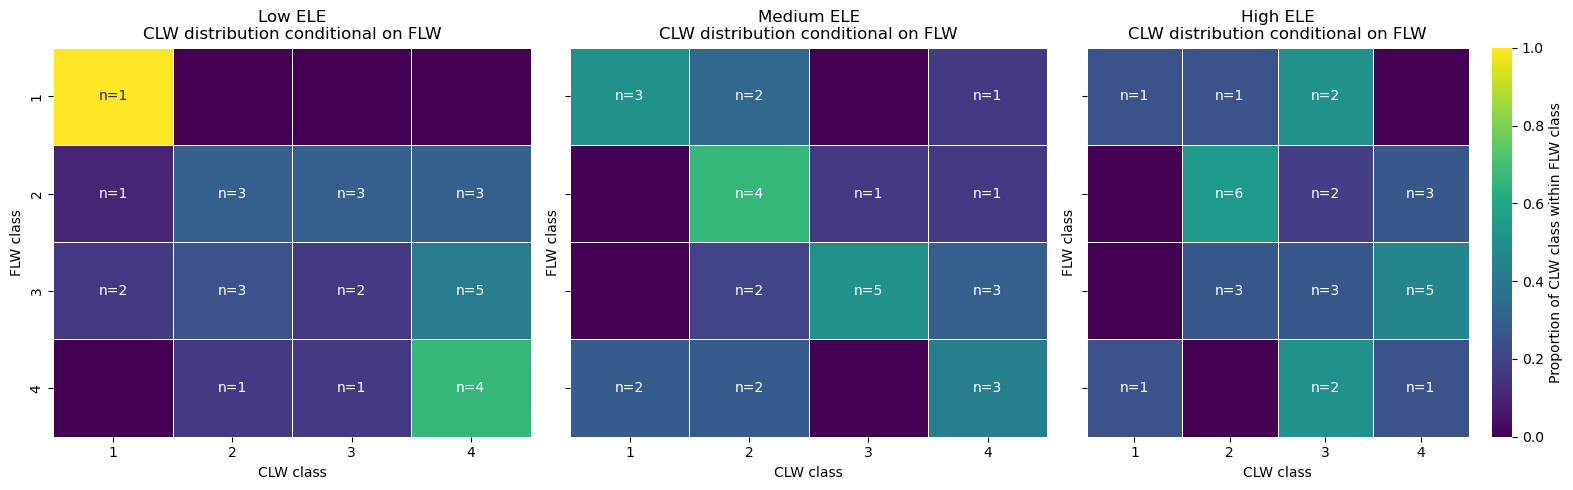


ELE tertile summary:


,ELE_tertile,n,min_ELE,median_ELE,max_ELE,pct_FLW_high,pct_CLW_high,pct_FLW_high_and_CLW_high
0,Low ELE,29,1.026300,1.653956,3.337846,62.068966,62.068966,41.379310
1,Medium ELE,29,3.355415,4.586865,5.779830,58.620690,48.275862,37.931034
2,High ELE,30,5.789993,8.552048,12.086567,50.000000,60.000000,36.666667



Interpretation aid:
These heatmaps are exploratory. Because each tertile contains about one third of the dataset, some FLW × CLW cells may have very low n. Avoid interpreting cells with n < 3 as robust patterns.


In [10]:
# ============================================================
# CELL 4. Heatmaps FLW x CLW stratified by ELE tertiles
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    data = df_ele.copy()
except NameError:
    data = df_core.copy()

FLW_COL = "Dead_Wood"
CLW_COL = "LW_Presence"
ELE_COL = "ELE (EffectLatExp)"

for c in [FLW_COL, CLW_COL, ELE_COL]:
    data[c] = pd.to_numeric(data[c], errors="coerce")

df_tert = data.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()
df_tert[FLW_COL] = df_tert[FLW_COL].astype(int)
df_tert[CLW_COL] = df_tert[CLW_COL].astype(int)

classes = [1, 2, 3, 4]
tertiles = ["Low ELE", "Medium ELE", "High ELE"]

# ------------------------------------------------------------
# Robust ELE tertiles
# ------------------------------------------------------------
df_tert["ELE_rank"] = df_tert[ELE_COL].rank(method="first")

df_tert["ELE_tertile"] = pd.qcut(
    df_tert["ELE_rank"],
    q=3,
    labels=tertiles
)

print("\nELE tertile distribution:")
display(df_tert["ELE_tertile"].value_counts().sort_index())

# Save tertile thresholds
tertile_thresholds = (
    df_tert
    .groupby("ELE_tertile")[ELE_COL]
    .agg(n="count", min_ELE="min", median_ELE="median", max_ELE="max")
    .reset_index()
)

print("\nELE tertile thresholds:")
display(tertile_thresholds)

tertile_thresholds.to_csv(OUT_DIR / "ELE_tertile_thresholds.csv", index=False)

# ------------------------------------------------------------
# Heatmaps: proportion relative to total n within each ELE tertile
# ------------------------------------------------------------
matrices_total = {}

for tert in tertiles:
    sub = df_tert[df_tert["ELE_tertile"] == tert]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes, columns=classes, fill_value=0)

    total_n = counts.to_numpy().sum()

    if total_n > 0:
        prop = counts / total_n
    else:
        prop = counts * np.nan

    matrices_total[tert] = prop

common_vmax = max(
    np.nanmax(m.to_numpy()) for m in matrices_total.values()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, tert in zip(axes, tertiles):
    sub = df_tert[df_tert["ELE_tertile"] == tert]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes, columns=classes, fill_value=0)

    prop = matrices_total[tert]

    annot = counts.copy().astype(object)

    for i in classes:
        for j in classes:
            n = counts.loc[i, j]
            annot.loc[i, j] = f"n={n}" if n > 0 else ""

    sns.heatmap(
        prop,
        ax=ax,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=common_vmax,
        linewidths=0.5,
        linecolor="white",
        cbar=ax == axes[-1],
        cbar_kws={"label": "Proportion within ELE tertile"}
    )

    ax.set_title(
        f"{tert}\n"
        f"median ELE={sub[ELE_COL].median():.2f}, n={len(sub)}"
    )
    ax.set_xlabel("CLW class")
    ax.set_ylabel("FLW class")

plt.tight_layout()
plt.savefig(OUT_DIR / "Heatmaps_FLW_CLW_by_ELE_tertiles.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Row-wise heatmaps:
# CLW distribution conditional on FLW, within each ELE tertile
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, tert in zip(axes, tertiles):
    sub = df_tert[df_tert["ELE_tertile"] == tert]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes, columns=classes, fill_value=0)

    row_sums = counts.sum(axis=1).replace(0, np.nan)
    row_prop = counts.div(row_sums, axis=0)

    annot = counts.copy().astype(object)

    for i in classes:
        for j in classes:
            n = counts.loc[i, j]
            annot.loc[i, j] = f"n={n}" if n > 0 else ""

    sns.heatmap(
        row_prop,
        ax=ax,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=ax == axes[-1],
        cbar_kws={"label": "Proportion of CLW class within FLW class"}
    )

    ax.set_title(
        f"{tert}\n"
        f"CLW distribution conditional on FLW"
    )
    ax.set_xlabel("CLW class")
    ax.set_ylabel("FLW class")

plt.tight_layout()
plt.savefig(OUT_DIR / "Heatmaps_CLW_given_FLW_by_ELE_tertiles.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Tertile summary table
# ------------------------------------------------------------
tert_summary = (
    df_tert
    .groupby("ELE_tertile")
    .agg(
        n=(ELE_COL, "count"),
        min_ELE=(ELE_COL, "min"),
        median_ELE=(ELE_COL, "median"),
        max_ELE=(ELE_COL, "max"),
        pct_FLW_high=(FLW_COL, lambda x: 100 * np.mean(x >= 3)),
        pct_CLW_high=(CLW_COL, lambda x: 100 * np.mean(x >= 3))
    )
    .reset_index()
)

both_high = (
    df_tert
    .assign(FLW_CLW_high=lambda d: (d[FLW_COL] >= 3) & (d[CLW_COL] >= 3))
    .groupby("ELE_tertile")["FLW_CLW_high"]
    .mean()
    .mul(100)
    .reset_index(name="pct_FLW_high_and_CLW_high")
)

tert_summary = tert_summary.merge(
    both_high,
    on="ELE_tertile",
    how="left"
)

print("\nELE tertile summary:")
display(tert_summary)

tert_summary.to_csv(OUT_DIR / "ELE_tertile_summary.csv", index=False)

print("\nInterpretation aid:")
print(
    "These heatmaps are exploratory. Because each tertile contains about one third of the dataset, "
    "some FLW × CLW cells may have very low n. Avoid interpreting cells with n < 3 as robust patterns."
)


Somers' D between FLW and CLW overall and by ELE tertile:


,ELE_group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Low ELE,29,0.271429,0.083103,-0.043702,0.537609
2,Medium ELE,29,0.254839,0.181962,-0.112306,0.638073
3,High ELE,30,0.210863,0.174204,-0.102679,0.487431


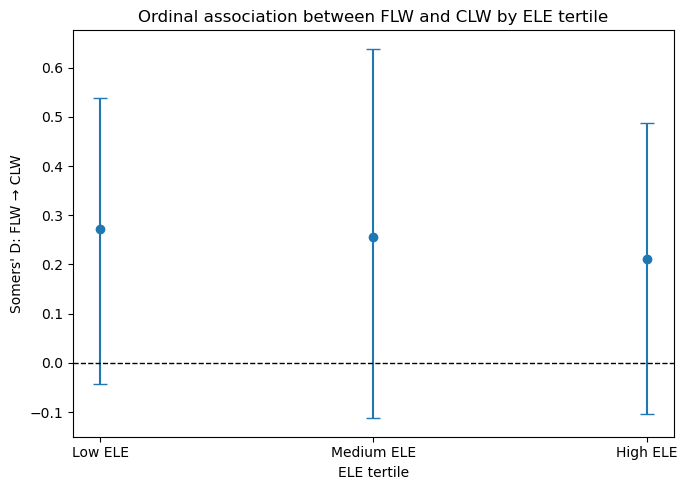


Interpretation aid:
Low ELE Somers' D: 0.271
Medium ELE Somers' D: 0.255
High ELE Somers' D: 0.211
The FLW–CLW association does not increase from Low ELE to High ELE. This does not support a clear exposure-dependent coupling in these data.
Somers' D by tertile evaluates whether the ordinal FLW–CLW association changes across ELE classes. It does not demonstrate hydraulic connectivity, wood recruitment, or causal transfer.


In [11]:
# ============================================================
# CELL 5. Somers' D between FLW and CLW overall and by ELE tertile
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Requires df_tert from Cell 4.
# If Cell 4 was not run, recreate df_tert here.
try:
    df_tert
except NameError:
    try:
        data = df_ele.copy()
    except NameError:
        data = df_core.copy()

    FLW_COL = "Dead_Wood"
    CLW_COL = "LW_Presence"
    ELE_COL = "ELE (EffectLatExp)"

    for c in [FLW_COL, CLW_COL, ELE_COL]:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    df_tert = data.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()
    df_tert[FLW_COL] = df_tert[FLW_COL].astype(int)
    df_tert[CLW_COL] = df_tert[CLW_COL].astype(int)

    tertiles = ["Low ELE", "Medium ELE", "High ELE"]
    df_tert["ELE_rank"] = df_tert[ELE_COL].rank(method="first")
    df_tert["ELE_tertile"] = pd.qcut(
        df_tert["ELE_rank"],
        q=3,
        labels=tertiles
    )

def somers_d_xy(data, x_col, y_col):
    """
    Directional Somers' D.
    x = FLW
    y = CLW
    Interpretation: ordinal association of CLW with increasing FLW.
    """

    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 5:
        return np.nan, np.nan

    if tmp[x_col].nunique() < 2 or tmp[y_col].nunique() < 2:
        return np.nan, np.nan

    try:
        res = stats.somersd(tmp[x_col], tmp[y_col])
        return res.statistic, res.pvalue
    except Exception:
        # fallback if somersd is unavailable
        tau, p = stats.kendalltau(tmp[x_col], tmp[y_col])
        return tau, p

def bootstrap_somers(data, x_col, y_col, n_boot=1000, seed=123):
    """
    Bootstrap CI for Somers' D.
    """

    rng = np.random.default_rng(seed)
    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 8:
        return np.nan, np.nan

    vals = []

    for _ in range(n_boot):
        sample_idx = rng.integers(0, tmp.shape[0], tmp.shape[0])
        sample = tmp.iloc[sample_idx]

        d, _ = somers_d_xy(sample, x_col, y_col)

        if pd.notna(d):
            vals.append(d)

    if len(vals) < 50:
        return np.nan, np.nan

    return np.percentile(vals, 2.5), np.percentile(vals, 97.5)

rows = []

# Overall
d_all, p_all = somers_d_xy(df_tert, FLW_COL, CLW_COL)
ci_low_all, ci_high_all = bootstrap_somers(df_tert, FLW_COL, CLW_COL)

rows.append({
    "ELE_group": "All data",
    "n": df_tert[[FLW_COL, CLW_COL]].dropna().shape[0],
    "Somers_D_FLW_to_CLW": d_all,
    "p_value": p_all,
    "CI_low": ci_low_all,
    "CI_high": ci_high_all
})

# By ELE tertile
tertiles = ["Low ELE", "Medium ELE", "High ELE"]

for tert in tertiles:
    sub = df_tert[df_tert["ELE_tertile"] == tert].copy()

    d, p = somers_d_xy(sub, FLW_COL, CLW_COL)
    ci_low, ci_high = bootstrap_somers(sub, FLW_COL, CLW_COL)

    rows.append({
        "ELE_group": tert,
        "n": sub[[FLW_COL, CLW_COL]].dropna().shape[0],
        "Somers_D_FLW_to_CLW": d,
        "p_value": p,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

somers_table = pd.DataFrame(rows)

print("\nSomers' D between FLW and CLW overall and by ELE tertile:")
display(somers_table)

somers_table.to_csv(OUT_DIR / "SomersD_FLW_CLW_by_ELE_tertile.csv", index=False)

# ------------------------------------------------------------
# Plot Somers' D by ELE tertile
# ------------------------------------------------------------
plot_df = somers_table[somers_table["ELE_group"] != "All data"].copy()

plt.figure(figsize=(7, 5))

x = np.arange(len(plot_df))
y = plot_df["Somers_D_FLW_to_CLW"].values

ci_low = plot_df["CI_low"].values
ci_high = plot_df["CI_high"].values

# Error bars only if CIs are finite
if np.all(np.isfinite(ci_low)) and np.all(np.isfinite(ci_high)):
    yerr_lower = y - ci_low
    yerr_upper = ci_high - y

    plt.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=5
    )
else:
    plt.plot(x, y, "o")

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xticks(x, plot_df["ELE_group"])
plt.ylabel("Somers' D: FLW → CLW")
plt.xlabel("ELE tertile")
plt.title("Ordinal association between FLW and CLW by ELE tertile")
plt.tight_layout()
plt.savefig(OUT_DIR / "SomersD_FLW_CLW_by_ELE_tertile.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Short interpretation aid
# ------------------------------------------------------------
print("\nInterpretation aid:")

valid = plot_df.dropna(subset=["Somers_D_FLW_to_CLW"])

if valid.shape[0] == 3:
    low = valid.loc[valid["ELE_group"] == "Low ELE", "Somers_D_FLW_to_CLW"].iloc[0]
    mid = valid.loc[valid["ELE_group"] == "Medium ELE", "Somers_D_FLW_to_CLW"].iloc[0]
    high = valid.loc[valid["ELE_group"] == "High ELE", "Somers_D_FLW_to_CLW"].iloc[0]

    print(f"Low ELE Somers' D: {low:.3f}")
    print(f"Medium ELE Somers' D: {mid:.3f}")
    print(f"High ELE Somers' D: {high:.3f}")

    if high > low:
        print(
            "The FLW–CLW association is stronger in High ELE than in Low ELE. "
            "This is consistent with a possible exposure-dependent coupling, but remains exploratory."
        )
    else:
        print(
            "The FLW–CLW association does not increase from Low ELE to High ELE. "
            "This does not support a clear exposure-dependent coupling in these data."
        )

print(
    "Somers' D by tertile evaluates whether the ordinal FLW–CLW association changes across ELE classes. "
    "It does not demonstrate hydraulic connectivity, wood recruitment, or causal transfer."
)


Somers' D between FLW and CLW overall and by ELE tertile:


,ELE_group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Low ELE,29,0.271429,0.083103,-0.043702,0.537609
2,Medium ELE,29,0.254839,0.181962,-0.112306,0.638073
3,High ELE,30,0.210863,0.174204,-0.102679,0.487431


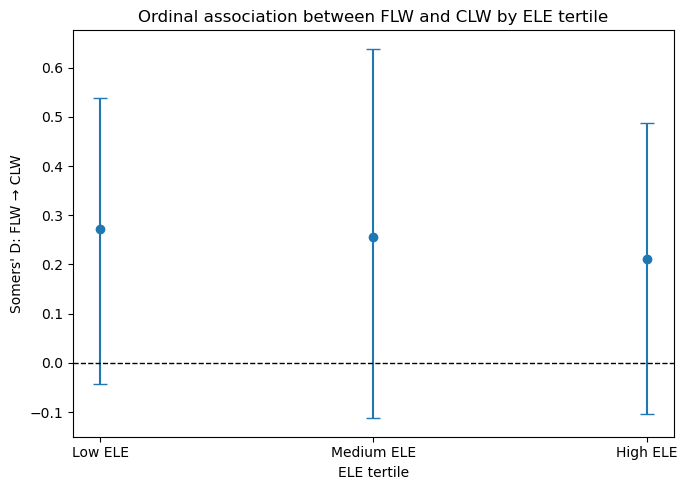


Interpretation aid:
Low ELE Somers' D: 0.271
Medium ELE Somers' D: 0.255
High ELE Somers' D: 0.211
The FLW–CLW association does not increase from Low ELE to High ELE. This does not support a clear exposure-dependent coupling in these data.
Somers' D by tertile evaluates whether the ordinal FLW–CLW association changes across ELE classes. It does not demonstrate hydraulic connectivity, wood recruitment, or causal transfer.


In [12]:
# ============================================================
# CELL 5. Somers' D between FLW and CLW overall and by ELE tertile
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Requires df_tert from Cell 4.
# If Cell 4 was not run, recreate df_tert here.
try:
    df_tert
except NameError:
    try:
        data = df_ele.copy()
    except NameError:
        data = df_core.copy()

    FLW_COL = "Dead_Wood"
    CLW_COL = "LW_Presence"
    ELE_COL = "ELE (EffectLatExp)"

    for c in [FLW_COL, CLW_COL, ELE_COL]:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    df_tert = data.dropna(subset=[FLW_COL, CLW_COL, ELE_COL]).copy()
    df_tert[FLW_COL] = df_tert[FLW_COL].astype(int)
    df_tert[CLW_COL] = df_tert[CLW_COL].astype(int)

    tertiles = ["Low ELE", "Medium ELE", "High ELE"]
    df_tert["ELE_rank"] = df_tert[ELE_COL].rank(method="first")
    df_tert["ELE_tertile"] = pd.qcut(
        df_tert["ELE_rank"],
        q=3,
        labels=tertiles
    )

def somers_d_xy(data, x_col, y_col):
    """
    Directional Somers' D.
    x = FLW
    y = CLW
    Interpretation: ordinal association of CLW with increasing FLW.
    """

    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 5:
        return np.nan, np.nan

    if tmp[x_col].nunique() < 2 or tmp[y_col].nunique() < 2:
        return np.nan, np.nan

    try:
        res = stats.somersd(tmp[x_col], tmp[y_col])
        return res.statistic, res.pvalue
    except Exception:
        # fallback if somersd is unavailable
        tau, p = stats.kendalltau(tmp[x_col], tmp[y_col])
        return tau, p

def bootstrap_somers(data, x_col, y_col, n_boot=1000, seed=123):
    """
    Bootstrap CI for Somers' D.
    """

    rng = np.random.default_rng(seed)
    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 8:
        return np.nan, np.nan

    vals = []

    for _ in range(n_boot):
        sample_idx = rng.integers(0, tmp.shape[0], tmp.shape[0])
        sample = tmp.iloc[sample_idx]

        d, _ = somers_d_xy(sample, x_col, y_col)

        if pd.notna(d):
            vals.append(d)

    if len(vals) < 50:
        return np.nan, np.nan

    return np.percentile(vals, 2.5), np.percentile(vals, 97.5)

rows = []

# Overall
d_all, p_all = somers_d_xy(df_tert, FLW_COL, CLW_COL)
ci_low_all, ci_high_all = bootstrap_somers(df_tert, FLW_COL, CLW_COL)

rows.append({
    "ELE_group": "All data",
    "n": df_tert[[FLW_COL, CLW_COL]].dropna().shape[0],
    "Somers_D_FLW_to_CLW": d_all,
    "p_value": p_all,
    "CI_low": ci_low_all,
    "CI_high": ci_high_all
})

# By ELE tertile
tertiles = ["Low ELE", "Medium ELE", "High ELE"]

for tert in tertiles:
    sub = df_tert[df_tert["ELE_tertile"] == tert].copy()

    d, p = somers_d_xy(sub, FLW_COL, CLW_COL)
    ci_low, ci_high = bootstrap_somers(sub, FLW_COL, CLW_COL)

    rows.append({
        "ELE_group": tert,
        "n": sub[[FLW_COL, CLW_COL]].dropna().shape[0],
        "Somers_D_FLW_to_CLW": d,
        "p_value": p,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

somers_table = pd.DataFrame(rows)

print("\nSomers' D between FLW and CLW overall and by ELE tertile:")
display(somers_table)

somers_table.to_csv(OUT_DIR / "SomersD_FLW_CLW_by_ELE_tertile.csv", index=False)

# ------------------------------------------------------------
# Plot Somers' D by ELE tertile
# ------------------------------------------------------------
plot_df = somers_table[somers_table["ELE_group"] != "All data"].copy()

plt.figure(figsize=(7, 5))

x = np.arange(len(plot_df))
y = plot_df["Somers_D_FLW_to_CLW"].values

ci_low = plot_df["CI_low"].values
ci_high = plot_df["CI_high"].values

# Error bars only if CIs are finite
if np.all(np.isfinite(ci_low)) and np.all(np.isfinite(ci_high)):
    yerr_lower = y - ci_low
    yerr_upper = ci_high - y

    plt.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=5
    )
else:
    plt.plot(x, y, "o")

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xticks(x, plot_df["ELE_group"])
plt.ylabel("Somers' D: FLW → CLW")
plt.xlabel("ELE tertile")
plt.title("Ordinal association between FLW and CLW by ELE tertile")
plt.tight_layout()
plt.savefig(OUT_DIR / "SomersD_FLW_CLW_by_ELE_tertile.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Short interpretation aid
# ------------------------------------------------------------
print("\nInterpretation aid:")

valid = plot_df.dropna(subset=["Somers_D_FLW_to_CLW"])

if valid.shape[0] == 3:
    low = valid.loc[valid["ELE_group"] == "Low ELE", "Somers_D_FLW_to_CLW"].iloc[0]
    mid = valid.loc[valid["ELE_group"] == "Medium ELE", "Somers_D_FLW_to_CLW"].iloc[0]
    high = valid.loc[valid["ELE_group"] == "High ELE", "Somers_D_FLW_to_CLW"].iloc[0]

    print(f"Low ELE Somers' D: {low:.3f}")
    print(f"Medium ELE Somers' D: {mid:.3f}")
    print(f"High ELE Somers' D: {high:.3f}")

    if high > low:
        print(
            "The FLW–CLW association is stronger in High ELE than in Low ELE. "
            "This is consistent with a possible exposure-dependent coupling, but remains exploratory."
        )
    else:
        print(
            "The FLW–CLW association does not increase from Low ELE to High ELE. "
            "This does not support a clear exposure-dependent coupling in these data."
        )

print(
    "Somers' D by tertile evaluates whether the ordinal FLW–CLW association changes across ELE classes. "
    "It does not demonstrate hydraulic connectivity, wood recruitment, or causal transfer."
)

In [13]:
# ============================================================
# CELL 7. Automatic concise interpretation
# ============================================================

import numpy as np
import pandas as pd

print("\n====================")
print("AUTOMATIC SUMMARY")
print("====================")

# ------------------------------------------------------------
# 1. ELE redundancy with ValleyConfinIndex
# ------------------------------------------------------------
try:
    rho_ev, p_ev, n_ev = spearman_pair(df_ele, ELE_COL, VALLEY_COL)

    print(f"1. ELE vs ValleyConfinIndex: rho={rho_ev:.3f}, p={p_ev:.4g}, n={n_ev}.")

    if abs(rho_ev) > 0.90:
        print(
            "   ELE is very strongly correlated with ValleyConfinIndex. "
            "This indicates that ELE is mostly dominated by the natural valley-confinement component."
        )
    elif abs(rho_ev) > 0.70:
        print(
            "   ELE is strongly correlated with ValleyConfinIndex. "
            "This suggests substantial redundancy."
        )
    else:
        print(
            "   ELE is not strongly correlated with ValleyConfinIndex. "
            "The artificial weighting substantially modifies the natural confinement signal."
        )

except Exception as e:
    print("1. ELE vs ValleyConfinIndex could not be summarized.")
    print(e)

# ------------------------------------------------------------
# 2. Lat_Connectivity modification
# ------------------------------------------------------------
try:
    n_modified = int((df_ele[LAT_COL] < 4).sum())
    pct_modified = 100 * n_modified / df_ele[LAT_COL].notna().sum()

    print(f"2. Cases with Lat_Connectivity < 4: {n_modified} ({pct_modified:.1f}%).")

    if pct_modified < 20:
        print(
            "   The artificial component modifies only a minority of observations. "
            "Therefore, ELE should not be interpreted as strongly independent from ValleyConfinIndex."
        )
    else:
        print(
            "   The artificial component modifies a substantial fraction of observations."
        )

except Exception as e:
    print("2. Lat_Connectivity modification could not be summarized.")
    print(e)

# ------------------------------------------------------------
# 3. Direct ELE relationships with FLW and CLW
# ------------------------------------------------------------
try:
    print("\n3. Direct bivariate relationships with ELE:")

    for _, row in biv_results.iterrows():
        resp = row["response"]
        rho = row["spearman_rho"]
        p = row["spearman_p"]

        print(f"   ELE vs {resp}: Spearman rho={rho:.3f}, p={p:.4g}.")

        if p < 0.05:
            print(
                f"   A statistically detectable monotonic association was found between ELE and {resp}, "
                "but it should be interpreted as association, not causation."
            )
        else:
            print(
                f"   No clear monotonic association was detected between ELE and {resp}."
            )

except Exception as e:
    print("3. Bivariate ELE relationships could not be summarized.")
    print(e)

# ------------------------------------------------------------
# 4. FLW–CLW association by ELE tertile
# ------------------------------------------------------------
try:
    print("\n4. Somers' D FLW→CLW by ELE tertile:")

    display(somers_table)

    tert_only = somers_table[somers_table["ELE_group"].isin(["Low ELE", "Medium ELE", "High ELE"])].copy()
    tert_only = tert_only.dropna(subset=["Somers_D_FLW_to_CLW"])

    if tert_only.shape[0] == 3:
        low = tert_only.loc[tert_only["ELE_group"] == "Low ELE", "Somers_D_FLW_to_CLW"].iloc[0]
        high = tert_only.loc[tert_only["ELE_group"] == "High ELE", "Somers_D_FLW_to_CLW"].iloc[0]

        if high > low:
            print(
                "   The FLW–CLW ordinal association appears stronger in High ELE than in Low ELE. "
                "This is consistent with possible exposure-dependent coupling, but remains exploratory."
            )
        else:
            print(
                "   The FLW–CLW ordinal association does not increase from Low ELE to High ELE. "
                "This does not support a clear exposure-dependent coupling."
            )

except Exception as e:
    print("4. Somers' D by ELE tertile could not be summarized.")
    print(e)

# ------------------------------------------------------------
# Final recommendation
# ------------------------------------------------------------
print("\nFinal recommendation:")
print(
    "Use ELE as a contextual or sensitivity descriptor of effective lateral exposure. "
    "Do not treat it as a direct measure of hydraulic lateral connectivity, inundation frequency, "
    "bank erosion, or observed wood recruitment. "
    "Its strongest potential use is to contextualize the FLW–CLW relationship, not to replace "
    "the main riparian and geomorphic predictors."
)

print(f"\nAll outputs saved in: {OUT_DIR}")


AUTOMATIC SUMMARY
1. ELE vs ValleyConfinIndex: rho=0.934, p=4.072e-40, n=88.
   ELE is very strongly correlated with ValleyConfinIndex. This indicates that ELE is mostly dominated by the natural valley-confinement component.
2. Cases with Lat_Connectivity < 4: 14 (15.9%).
   The artificial component modifies only a minority of observations. Therefore, ELE should not be interpreted as strongly independent from ValleyConfinIndex.

3. Direct bivariate relationships with ELE:
   ELE vs Dead_Wood: Spearman rho=-0.132, p=0.2216.
   No clear monotonic association was detected between ELE and Dead_Wood.
   ELE vs LW_Presence: Spearman rho=-0.009, p=0.9356.
   No clear monotonic association was detected between ELE and LW_Presence.

4. Somers' D FLW→CLW by ELE tertile:


,ELE_group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Low ELE,29,0.271429,0.083103,-0.043702,0.537609
2,Medium ELE,29,0.254839,0.181962,-0.112306,0.638073
3,High ELE,30,0.210863,0.174204,-0.102679,0.487431


   The FLW–CLW ordinal association does not increase from Low ELE to High ELE. This does not support a clear exposure-dependent coupling.

Final recommendation:
Use ELE as a contextual or sensitivity descriptor of effective lateral exposure. Do not treat it as a direct measure of hydraulic lateral connectivity, inundation frequency, bank erosion, or observed wood recruitment. Its strongest potential use is to contextualize the FLW–CLW relationship, not to replace the main riparian and geomorphic predictors.

All outputs saved in: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\ELE_analysis_outputs


In [14]:
# ============================================================
# CELL A. Create Effective Lateral Exposure Class
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Use df_ele if available; otherwise use df_core
# ------------------------------------------------------------
try:
    data_cls = df_ele.copy()
except NameError:
    data_cls = df_core.copy()

# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------
FLW_COL = "Dead_Wood"              # FLW
CLW_COL = "LW_Presence"            # CLW
VALLEY_COL = "ValleyConfinIndex"
LAT_COL = "Lat_Connectivity"
ELE_COL = "ELE (EffectLatExp)"

# ------------------------------------------------------------
# Ensure numeric
# ------------------------------------------------------------
for c in [FLW_COL, CLW_COL, VALLEY_COL, LAT_COL, ELE_COL]:
    if c in data_cls.columns:
        data_cls[c] = pd.to_numeric(data_cls[c], errors="coerce")

needed = [FLW_COL, CLW_COL, VALLEY_COL, LAT_COL]
missing = [c for c in needed if c not in data_cls.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

data_cls = data_cls.dropna(subset=needed).copy()

data_cls[FLW_COL] = data_cls[FLW_COL].astype(int)
data_cls[CLW_COL] = data_cls[CLW_COL].astype(int)
data_cls[LAT_COL] = data_cls[LAT_COL].astype(int)

# ------------------------------------------------------------
# 1. Natural lateral accommodation class from ValleyConfinIndex
# Higher class = greater natural lateral accommodation
# ------------------------------------------------------------
def classify_natural_accommodation(v):
    if pd.isna(v):
        return np.nan
    elif v <= 2:
        return 1   # confined / low natural accommodation
    elif v <= 4:
        return 2   # partly confined / moderate natural accommodation
    else:
        return 3   # unconfined / high natural accommodation

data_cls["NaturalLatAccommodationClass"] = data_cls[VALLEY_COL].apply(classify_natural_accommodation)

# ------------------------------------------------------------
# 2. Artificial cap based on Lat_Connectivity
# Higher cap = less artificial restriction
# ------------------------------------------------------------
def artificial_cap(lat):
    if pd.isna(lat):
        return np.nan
    elif lat == 4:
        return 3   # no apparent artificial restriction
    elif lat == 3:
        return 2   # partial/light artificial restriction
    elif lat == 2:
        return 2   # moderate artificial restriction
    elif lat == 1:
        return 1   # strong artificial restriction
    else:
        return np.nan

data_cls["ArtificialExposureCap"] = data_cls[LAT_COL].apply(artificial_cap)

# ------------------------------------------------------------
# 3. Effective lateral exposure class
# Final class cannot exceed artificial cap
# ------------------------------------------------------------
data_cls["EffLatExpClass"] = data_cls[
    ["NaturalLatAccommodationClass", "ArtificialExposureCap"]
].min(axis=1)

data_cls["EffLatExpClass"] = data_cls["EffLatExpClass"].astype(int)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
class_labels = {
    1: "Low effective lateral exposure",
    2: "Moderate effective lateral exposure",
    3: "High effective lateral exposure"
}

data_cls["EffLatExpClassLabel"] = data_cls["EffLatExpClass"].map(class_labels)

natural_labels = {
    1: "Confined / low natural accommodation",
    2: "Partly confined / moderate natural accommodation",
    3: "Unconfined / high natural accommodation"
}

data_cls["NaturalLatAccommodationLabel"] = data_cls["NaturalLatAccommodationClass"].map(natural_labels)

# ------------------------------------------------------------
# Show distributions
# ------------------------------------------------------------
print("\nNatural lateral accommodation class distribution:")
display(
    data_cls["NaturalLatAccommodationClass"]
    .value_counts()
    .sort_index()
    .rename_axis("NaturalLatAccommodationClass")
    .reset_index(name="n")
)

print("\nArtificial exposure cap distribution:")
display(
    data_cls["ArtificialExposureCap"]
    .value_counts()
    .sort_index()
    .rename_axis("ArtificialExposureCap")
    .reset_index(name="n")
)

print("\nEffective lateral exposure class distribution:")
eff_class_dist = (
    data_cls["EffLatExpClass"]
    .value_counts()
    .sort_index()
    .rename_axis("EffLatExpClass")
    .reset_index(name="n")
)

eff_class_dist["percent"] = 100 * eff_class_dist["n"] / eff_class_dist["n"].sum()

display(eff_class_dist)

# ------------------------------------------------------------
# Cross-tab: natural class vs final effective class
# ------------------------------------------------------------
print("\nCross-tab: Natural class × Effective class")
nat_eff_crosstab = pd.crosstab(
    data_cls["NaturalLatAccommodationClass"],
    data_cls["EffLatExpClass"],
    margins=True
)

display(nat_eff_crosstab)

# ------------------------------------------------------------
# Cases where class was downgraded
# ------------------------------------------------------------
data_cls["ClassDowngrade"] = (
    data_cls["NaturalLatAccommodationClass"] - data_cls["EffLatExpClass"]
)

downgraded = data_cls[data_cls["ClassDowngrade"] > 0].copy()

print(f"\nNumber of downgraded observations: {len(downgraded)} / {len(data_cls)}")

cols_to_show = [
    "Id_RipUnit",
    "Id_Reach",
    "Basin",
    "Reach",
    "Bank",
    VALLEY_COL,
    LAT_COL,
    "NaturalLatAccommodationClass",
    "ArtificialExposureCap",
    "EffLatExpClass",
    "ClassDowngrade"
]

cols_to_show = [c for c in cols_to_show if c in data_cls.columns]

display(downgraded[cols_to_show].sort_values(["ClassDowngrade", LAT_COL], ascending=[False, True]))

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
data_cls.to_csv(OUT_DIR / "dataset_with_EffectiveLateralExposureClass.csv", index=False)
eff_class_dist.to_csv(OUT_DIR / "EffLatExpClass_distribution.csv", index=False)
nat_eff_crosstab.to_csv(OUT_DIR / "Natural_vs_EffectiveLatExpClass_crosstab.csv")

print(f"\nOutputs saved in: {OUT_DIR}")


Natural lateral accommodation class distribution:


,NaturalLatAccommodationClass,n
0,1,14
1,2,22
2,3,52



Artificial exposure cap distribution:


,ArtificialExposureCap,n
0,1,2
1,2,12
2,3,74



Effective lateral exposure class distribution:


...


Cross-tab: Natural class × Effective class


EffLatExpClass,1,2,3,All
NaturalLatAccommodationClass,,,,
1,14,0,0,14
2,0,22,0,22
3,2,9,41,52
All,16,31,41,88



Number of downgraded observations: 11 / 88


,Id_RipUnit,Id_Reach,Basin,Reach,Bank,ValleyConfinIndex,Lat_Connectivity,NaturalLatAccommodationClass,ArtificialExposureCap,EffLatExpClass,ClassDowngrade
2,3,2,Arve,A-A2,Left,16.384272,1,3,1,1,2
3,4,2,Arve,A-A2,Right,17.158012,1,3,1,1,2
0,1,1,Arve,A-A1,Left,12.573561,2,3,2,2,1
11,12,6,Arve,A-A6,Right,9.555143,2,3,2,2,1
10,11,6,Arve,A-A6,Left,9.549191,3,3,2,2,1
16,17,9,Arve,A-A9,Left,8.628818,3,3,2,2,1
17,18,9,Arve,A-A9,Right,8.925979,3,3,2,2,1
20,21,11,Arve,A-A11,Left,7.706440,3,3,2,2,1
21,22,11,Arve,A-A11,Right,7.472858,3,3,2,2,1
32,33,17,Arve,A-A17,Left,7.887647,3,3,2,2,1



Outputs saved in: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\ELE_analysis_outputs


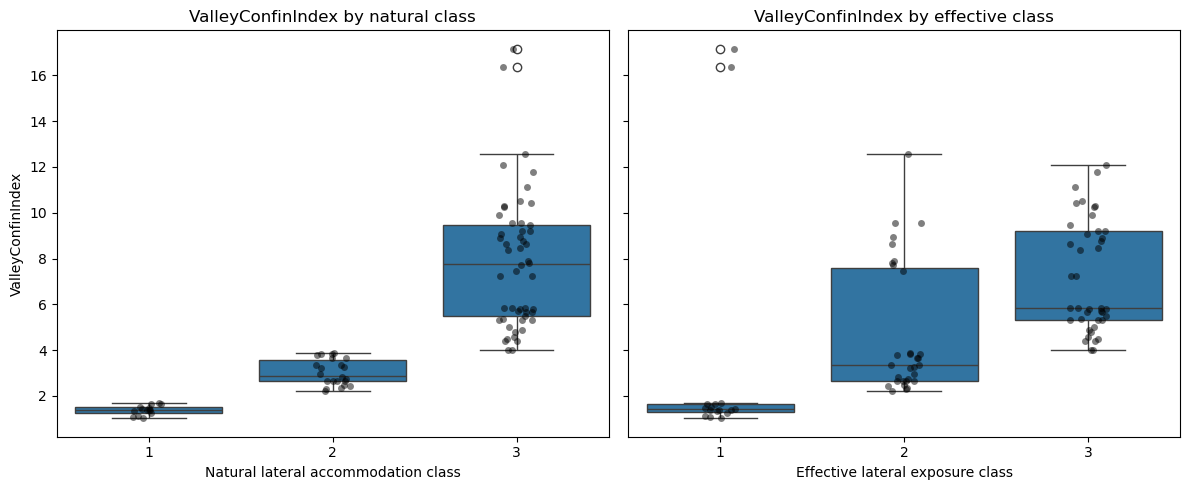

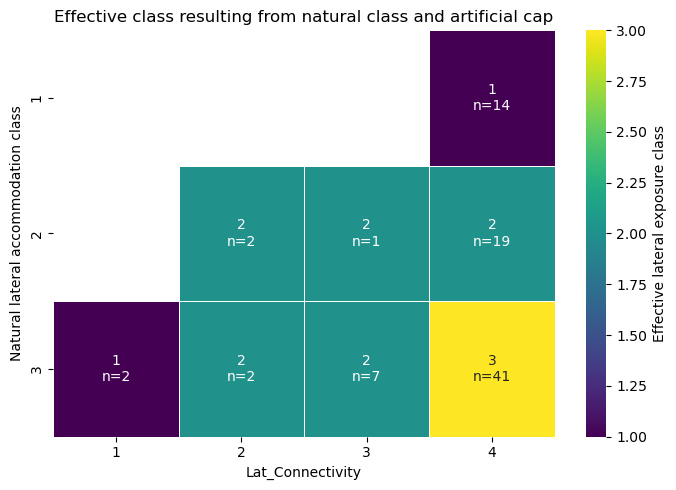

In [15]:
# ============================================================
# CELL B. Visual diagnostics for Effective Lateral Exposure Class
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. ValleyConfinIndex by natural and effective class
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.boxplot(
    data=data_cls,
    x="NaturalLatAccommodationClass",
    y=VALLEY_COL,
    ax=axes[0]
)

sns.stripplot(
    data=data_cls,
    x="NaturalLatAccommodationClass",
    y=VALLEY_COL,
    color="black",
    alpha=0.5,
    jitter=True,
    ax=axes[0]
)

axes[0].set_title("ValleyConfinIndex by natural class")
axes[0].set_xlabel("Natural lateral accommodation class")
axes[0].set_ylabel("ValleyConfinIndex")

sns.boxplot(
    data=data_cls,
    x="EffLatExpClass",
    y=VALLEY_COL,
    ax=axes[1]
)

sns.stripplot(
    data=data_cls,
    x="EffLatExpClass",
    y=VALLEY_COL,
    color="black",
    alpha=0.5,
    jitter=True,
    ax=axes[1]
)

axes[1].set_title("ValleyConfinIndex by effective class")
axes[1].set_xlabel("Effective lateral exposure class")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "ValleyConfinIndex_by_Natural_and_EffectiveClass.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Heatmap: Natural class × Lat_Connectivity -> Effective class
# ------------------------------------------------------------
summary_cap = (
    data_cls
    .groupby(["NaturalLatAccommodationClass", LAT_COL])["EffLatExpClass"]
    .agg(
        n="count",
        median_EffClass="median",
        min_EffClass="min",
        max_EffClass="max"
    )
    .reset_index()
)

pivot_eff = summary_cap.pivot(
    index="NaturalLatAccommodationClass",
    columns=LAT_COL,
    values="median_EffClass"
)

pivot_n = summary_cap.pivot(
    index="NaturalLatAccommodationClass",
    columns=LAT_COL,
    values="n"
)

annot = pivot_eff.copy().astype(object)

for i in pivot_eff.index:
    for j in pivot_eff.columns:
        val = pivot_eff.loc[i, j]
        n = pivot_n.loc[i, j]
        if pd.isna(val):
            annot.loc[i, j] = ""
        else:
            annot.loc[i, j] = f"{val:.0f}\nn={int(n)}"

plt.figure(figsize=(7, 5))

sns.heatmap(
    pivot_eff,
    annot=annot,
    fmt="",
    cmap="viridis",
    vmin=1,
    vmax=3,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Effective lateral exposure class"}
)

plt.xlabel("Lat_Connectivity")
plt.ylabel("Natural lateral accommodation class")
plt.title("Effective class resulting from natural class and artificial cap")
plt.tight_layout()
plt.savefig(OUT_DIR / "EffectiveClass_from_NaturalClass_and_LatConnectivity.png", dpi=300)
plt.show()


Ordinal associations: Effective lateral exposure class vs FLW and CLW


,predictor,response,Somers_D,p_value,n
0,EffLatExpClass,Dead_Wood,0.061081,0.532125,88
1,EffLatExpClass,LW_Presence,0.220801,0.024428,88


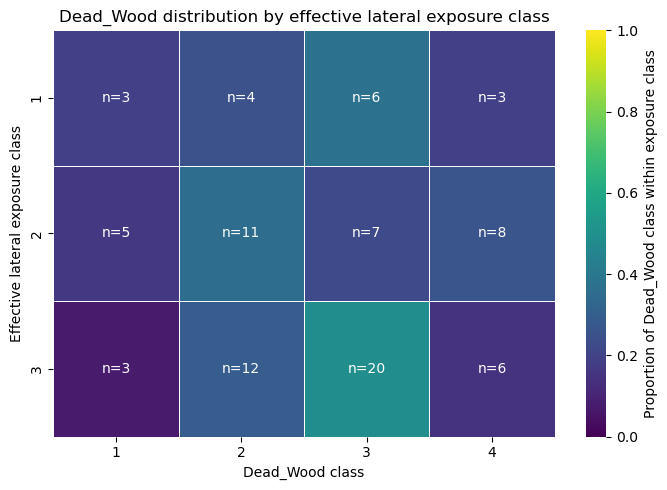

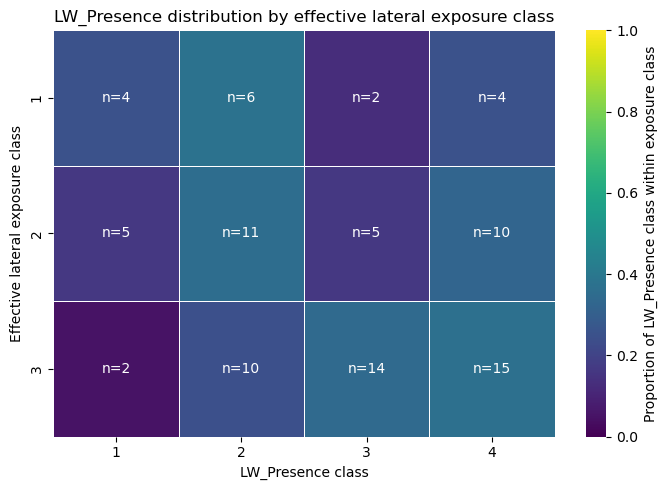


FLW counts by Effective lateral exposure class:


Dead_Wood,1,2,3,4
EffLatExpClass,,,,
1,3,4,6,3
2,5,11,7,8
3,3,12,20,6



CLW counts by Effective lateral exposure class:


LW_Presence,1,2,3,4
EffLatExpClass,,,,
1,4,6,2,4
2,5,11,5,10
3,2,10,14,15


In [16]:
# ============================================================
# CELL C. Ordinal associations:
# Effective lateral exposure class vs FLW and CLW
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

EFF_CLASS_COL = "EffLatExpClass"

def somers_d_xy(data, x_col, y_col):
    """
    Directional Somers' D.
    x = predictor
    y = response
    """
    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 5:
        return np.nan, np.nan, tmp.shape[0]

    if tmp[x_col].nunique() < 2 or tmp[y_col].nunique() < 2:
        return np.nan, np.nan, tmp.shape[0]

    try:
        res = stats.somersd(tmp[x_col], tmp[y_col])
        return res.statistic, res.pvalue, tmp.shape[0]
    except Exception:
        tau, p = stats.kendalltau(tmp[x_col], tmp[y_col])
        return tau, p, tmp.shape[0]

rows = []

for response in [FLW_COL, CLW_COL]:
    d, p, n = somers_d_xy(data_cls, EFF_CLASS_COL, response)
    rows.append({
        "predictor": EFF_CLASS_COL,
        "response": response,
        "Somers_D": d,
        "p_value": p,
        "n": n
    })

eff_biv_table = pd.DataFrame(rows)

print("\nOrdinal associations: Effective lateral exposure class vs FLW and CLW")
display(eff_biv_table)

eff_biv_table.to_csv(OUT_DIR / "EffLatExpClass_vs_FLW_CLW_SomersD.csv", index=False)

# ------------------------------------------------------------
# Heatmaps: response distribution by EffLatExpClass
# Row-wise proportions
# ------------------------------------------------------------
def response_heatmap_by_eff_class(data, response_col, output_name):
    ct = pd.crosstab(
        data[EFF_CLASS_COL],
        data[response_col]
    ).reindex(index=[1, 2, 3], columns=[1, 2, 3, 4], fill_value=0)

    row_prop = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)

    annot = ct.copy().astype(object)
    for i in ct.index:
        for j in ct.columns:
            n = ct.loc[i, j]
            annot.loc[i, j] = f"n={n}" if n > 0 else ""

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        row_prop,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": f"Proportion of {response_col} class within exposure class"}
    )

    plt.xlabel(f"{response_col} class")
    plt.ylabel("Effective lateral exposure class")
    plt.title(f"{response_col} distribution by effective lateral exposure class")
    plt.tight_layout()
    plt.savefig(OUT_DIR / output_name, dpi=300)
    plt.show()

    return ct, row_prop

flw_ct, flw_rowprop = response_heatmap_by_eff_class(
    data_cls,
    FLW_COL,
    "FLW_by_EffLatExpClass_heatmap.png"
)

clw_ct, clw_rowprop = response_heatmap_by_eff_class(
    data_cls,
    CLW_COL,
    "CLW_by_EffLatExpClass_heatmap.png"
)

print("\nFLW counts by Effective lateral exposure class:")
display(flw_ct)

print("\nCLW counts by Effective lateral exposure class:")
display(clw_ct)

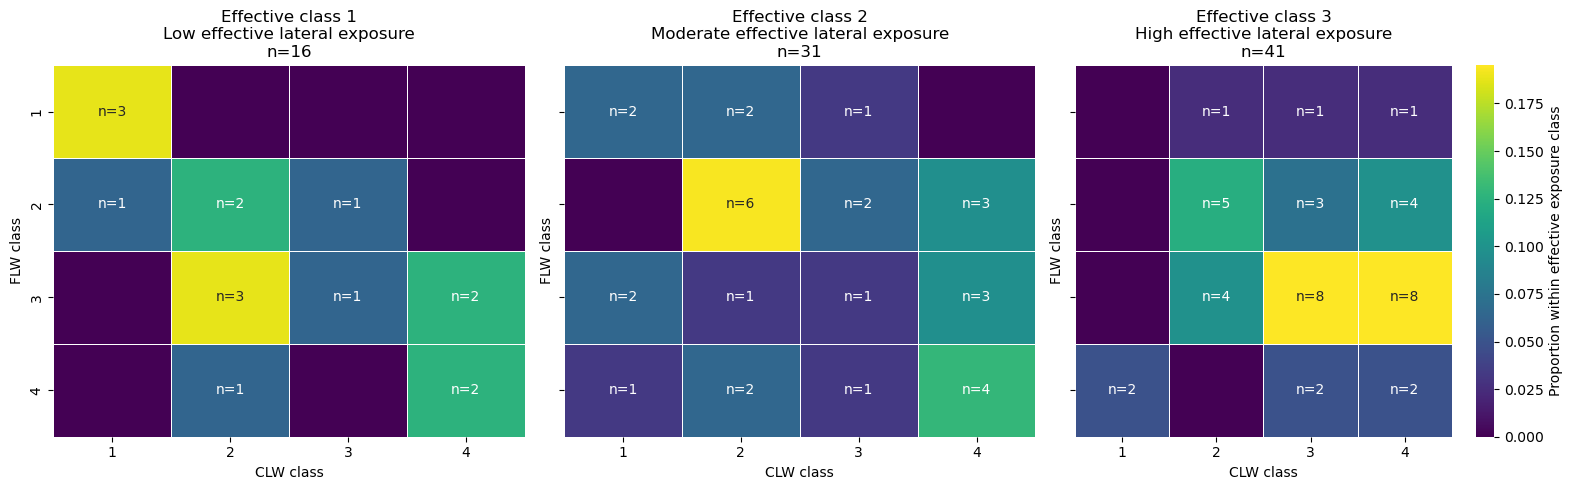

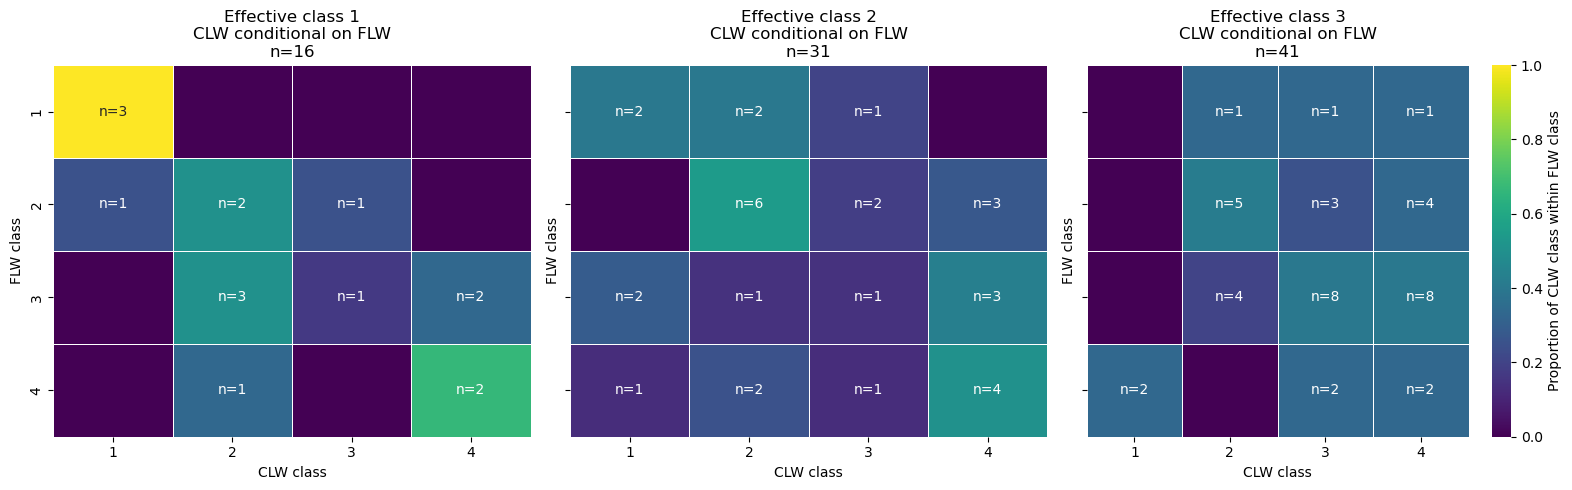


Summary by Effective lateral exposure class:


,EffLatExpClass,n,median_ValleyConfin,median_ELE,pct_FLW_high,pct_CLW_high,pct_FLW_high_and_CLW_high
0,1,16,1.414848,1.414848,56.250000,37.500000,31.250000
1,2,31,3.355415,3.355415,48.387097,48.387097,29.032258
2,3,41,5.846365,5.846365,63.414634,70.731707,48.780488


In [17]:
# ============================================================
# CELL D. FLW x CLW heatmaps stratified by Effective Lateral Exposure Class
# ============================================================

classes_flw = [1, 2, 3, 4]
classes_clw = [1, 2, 3, 4]
eff_classes = [1, 2, 3]

# ------------------------------------------------------------
# Heatmaps: proportion within each effective exposure class
# ------------------------------------------------------------
matrices_total = {}

for ec in eff_classes:
    sub = data_cls[data_cls[EFF_CLASS_COL] == ec]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes_flw, columns=classes_clw, fill_value=0)

    total = counts.to_numpy().sum()

    if total > 0:
        prop = counts / total
    else:
        prop = counts * np.nan

    matrices_total[ec] = prop

common_vmax = max(np.nanmax(m.to_numpy()) for m in matrices_total.values())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, ec in zip(axes, eff_classes):
    sub = data_cls[data_cls[EFF_CLASS_COL] == ec]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes_flw, columns=classes_clw, fill_value=0)

    prop = matrices_total[ec]

    annot = counts.copy().astype(object)

    for i in classes_flw:
        for j in classes_clw:
            n = counts.loc[i, j]
            annot.loc[i, j] = f"n={n}" if n > 0 else ""

    sns.heatmap(
        prop,
        ax=ax,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=common_vmax,
        linewidths=0.5,
        linecolor="white",
        cbar=ax == axes[-1],
        cbar_kws={"label": "Proportion within effective exposure class"}
    )

    ax.set_title(
        f"Effective class {ec}\n"
        f"{class_labels.get(ec, '')}\n"
        f"n={len(sub)}"
    )
    ax.set_xlabel("CLW class")
    ax.set_ylabel("FLW class")

plt.tight_layout()
plt.savefig(OUT_DIR / "FLW_CLW_by_EffLatExpClass_total_proportion.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Row-wise heatmaps:
# CLW distribution conditional on FLW within each effective class
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, ec in zip(axes, eff_classes):
    sub = data_cls[data_cls[EFF_CLASS_COL] == ec]

    counts = pd.crosstab(
        sub[FLW_COL],
        sub[CLW_COL]
    ).reindex(index=classes_flw, columns=classes_clw, fill_value=0)

    row_prop = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)

    annot = counts.copy().astype(object)

    for i in classes_flw:
        for j in classes_clw:
            n = counts.loc[i, j]
            annot.loc[i, j] = f"n={n}" if n > 0 else ""

    sns.heatmap(
        row_prop,
        ax=ax,
        annot=annot,
        fmt="",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=ax == axes[-1],
        cbar_kws={"label": "Proportion of CLW class within FLW class"}
    )

    ax.set_title(
        f"Effective class {ec}\n"
        f"CLW conditional on FLW\n"
        f"n={len(sub)}"
    )

    ax.set_xlabel("CLW class")
    ax.set_ylabel("FLW class")

plt.tight_layout()
plt.savefig(OUT_DIR / "CLW_given_FLW_by_EffLatExpClass.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Summary table by effective class
# ------------------------------------------------------------
eff_summary = (
    data_cls
    .groupby(EFF_CLASS_COL)
    .agg(
        n=(EFF_CLASS_COL, "count"),
        median_ValleyConfin=(VALLEY_COL, "median"),
        median_ELE=(ELE_COL, "median") if ELE_COL in data_cls.columns else (VALLEY_COL, "median"),
        pct_FLW_high=(FLW_COL, lambda x: 100 * np.mean(x >= 3)),
        pct_CLW_high=(CLW_COL, lambda x: 100 * np.mean(x >= 3))
    )
    .reset_index()
)

both_high = (
    data_cls
    .assign(FLW_CLW_high=lambda d: (d[FLW_COL] >= 3) & (d[CLW_COL] >= 3))
    .groupby(EFF_CLASS_COL)["FLW_CLW_high"]
    .mean()
    .mul(100)
    .reset_index(name="pct_FLW_high_and_CLW_high")
)

eff_summary = eff_summary.merge(both_high, on=EFF_CLASS_COL, how="left")

print("\nSummary by Effective lateral exposure class:")
display(eff_summary)

eff_summary.to_csv(OUT_DIR / "EffLatExpClass_summary_FLW_CLW.csv", index=False)


Somers' D FLW -> CLW overall and by Effective lateral exposure class:


,group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Effective class 1,16,0.645161,0.000012,0.314573,0.873244
2,Effective class 2,31,0.247863,0.096585,-0.055504,0.537524
3,Effective class 3,41,0.032967,0.832215,-0.257665,0.352732


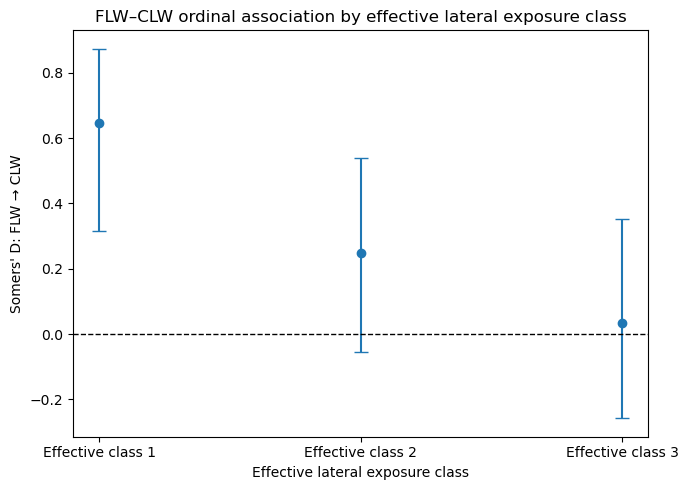


Interpretation aid:


,group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Effective class 1,16,0.645161,0.000012,0.314573,0.873244
2,Effective class 2,31,0.247863,0.096585,-0.055504,0.537524
3,Effective class 3,41,0.032967,0.832215,-0.257665,0.352732


Check whether Somers' D increases from effective class 1 to class 3. If it does not, there is no evidence that the FLW–CLW association strengthens with greater effective lateral exposure.
These results should be interpreted as exploratory sensitivity analyses. Effective lateral exposure class is not a direct measure of hydraulic connectivity, inundation frequency, floodplain elevation, bank erosion, or observed wood recruitment.


In [18]:
# ============================================================
# CELL E. Somers' D FLW -> CLW within each Effective Lateral Exposure Class
# ============================================================

def bootstrap_somers(data, x_col, y_col, n_boot=1000, seed=123):
    rng = np.random.default_rng(seed)

    tmp = data[[x_col, y_col]].dropna().copy()

    if tmp.shape[0] < 8:
        return np.nan, np.nan

    vals = []

    for _ in range(n_boot):
        sample_idx = rng.integers(0, tmp.shape[0], tmp.shape[0])
        sample = tmp.iloc[sample_idx]

        d, p, n = somers_d_xy(sample, x_col, y_col)

        if pd.notna(d):
            vals.append(d)

    if len(vals) < 50:
        return np.nan, np.nan

    return np.percentile(vals, 2.5), np.percentile(vals, 97.5)

rows = []

# Overall
d_all, p_all, n_all = somers_d_xy(data_cls, FLW_COL, CLW_COL)
ci_low_all, ci_high_all = bootstrap_somers(data_cls, FLW_COL, CLW_COL)

rows.append({
    "group": "All data",
    "n": n_all,
    "Somers_D_FLW_to_CLW": d_all,
    "p_value": p_all,
    "CI_low": ci_low_all,
    "CI_high": ci_high_all
})

# By effective class
for ec in eff_classes:
    sub = data_cls[data_cls[EFF_CLASS_COL] == ec].copy()

    d, p, n = somers_d_xy(sub, FLW_COL, CLW_COL)
    ci_low, ci_high = bootstrap_somers(sub, FLW_COL, CLW_COL)

    rows.append({
        "group": f"Effective class {ec}",
        "n": n,
        "Somers_D_FLW_to_CLW": d,
        "p_value": p,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

somers_eff_table = pd.DataFrame(rows)

print("\nSomers' D FLW -> CLW overall and by Effective lateral exposure class:")
display(somers_eff_table)

somers_eff_table.to_csv(OUT_DIR / "SomersD_FLW_CLW_by_EffLatExpClass.csv", index=False)

# ------------------------------------------------------------
# Plot Somers' D by effective class
# ------------------------------------------------------------
plot_df = somers_eff_table[somers_eff_table["group"] != "All data"].copy()

plt.figure(figsize=(7, 5))

x = np.arange(len(plot_df))
y = plot_df["Somers_D_FLW_to_CLW"].values

ci_low = plot_df["CI_low"].values
ci_high = plot_df["CI_high"].values

if np.all(np.isfinite(ci_low)) and np.all(np.isfinite(ci_high)):
    yerr_lower = y - ci_low
    yerr_upper = ci_high - y

    plt.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=5
    )
else:
    plt.plot(x, y, "o")

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xticks(x, plot_df["group"])
plt.ylabel("Somers' D: FLW → CLW")
plt.xlabel("Effective lateral exposure class")
plt.title("FLW–CLW ordinal association by effective lateral exposure class")
plt.tight_layout()
plt.savefig(OUT_DIR / "SomersD_FLW_CLW_by_EffLatExpClass.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Interpretation aid
# ------------------------------------------------------------
print("\nInterpretation aid:")

display(somers_eff_table)

valid = plot_df.dropna(subset=["Somers_D_FLW_to_CLW"])

if valid.shape[0] >= 2:
    print(
        "Check whether Somers' D increases from effective class 1 to class 3. "
        "If it does not, there is no evidence that the FLW–CLW association strengthens "
        "with greater effective lateral exposure."
    )

print(
    "These results should be interpreted as exploratory sensitivity analyses. "
    "Effective lateral exposure class is not a direct measure of hydraulic connectivity, "
    "inundation frequency, floodplain elevation, bank erosion, or observed wood recruitment."
)

In [19]:
# ============================================================
# CELL F. Final comparison:
# Continuous ELE vs Effective Lateral Exposure Class
# ============================================================

# ------------------------------------------------------------
# Continuous ELE bivariate results, if available
# ------------------------------------------------------------
try:
    print("\nContinuous ELE bivariate results:")
    display(biv_results)
except NameError:
    print("\nNo previous continuous ELE bivariate table found as 'biv_results'.")

# ------------------------------------------------------------
# Effective class bivariate results
# ------------------------------------------------------------
print("\nEffective class bivariate results:")
display(eff_biv_table)

# ------------------------------------------------------------
# Somers FLW -> CLW by continuous ELE tertiles, if available
# ------------------------------------------------------------
try:
    print("\nSomers' D FLW -> CLW by continuous ELE tertiles:")
    display(somers_table)
except NameError:
    print("\nNo previous Somers table by ELE tertiles found as 'somers_table'.")

# ------------------------------------------------------------
# Somers FLW -> CLW by effective class
# ------------------------------------------------------------
print("\nSomers' D FLW -> CLW by effective lateral exposure class:")
display(somers_eff_table)

# ------------------------------------------------------------
# Automatic summary
# ------------------------------------------------------------
print("\n====================")
print("FINAL SENSITIVITY SUMMARY")
print("====================")

n_downgraded = int((data_cls["ClassDowngrade"] > 0).sum())
pct_downgraded = 100 * n_downgraded / len(data_cls)

print(
    f"{n_downgraded} observations ({pct_downgraded:.1f}%) were downgraded "
    "from their natural lateral accommodation class due to artificial lateral constraints."
)

# Effective class vs FLW/CLW
for _, row in eff_biv_table.iterrows():
    response = row["response"]
    d = row["Somers_D"]
    p = row["p_value"]

    print(
        f"Effective lateral exposure class vs {response}: "
        f"Somers' D = {d:.3f}, p = {p:.4g}."
    )

    if p < 0.05:
        print(
            f"  A statistically detectable ordinal association was found with {response}, "
            "but this should not be interpreted causally."
        )
    else:
        print(
            f"  No clear ordinal association was detected with {response}."
        )

# FLW-CLW coupling by effective class
valid = somers_eff_table[
    somers_eff_table["group"].str.contains("Effective class", na=False)
].dropna(subset=["Somers_D_FLW_to_CLW"])

if valid.shape[0] >= 2:
    print("\nFLW–CLW association by effective class:")
    display(valid[["group", "n", "Somers_D_FLW_to_CLW", "p_value", "CI_low", "CI_high"]])

    if valid["Somers_D_FLW_to_CLW"].iloc[-1] > valid["Somers_D_FLW_to_CLW"].iloc[0]:
        print(
            "The FLW–CLW association appears stronger in higher effective exposure classes, "
            "but this must be checked against sample size and confidence intervals."
        )
    else:
        print(
            "The FLW–CLW association does not clearly increase with effective lateral exposure class."
        )

print(
    "\nRecommended interpretation: use the effective lateral exposure class as a conservative "
    "sensitivity analysis. If no clear pattern appears, report that lateral exposure was considered "
    "using both continuous and ordinal proxies, but neither provided strong evidence that the "
    "FLW–CLW relationship was conditioned by the available lateral-exposure descriptors."
)


Continuous ELE bivariate results:


,response,predictor,n,spearman_rho,spearman_p,kruskal_H,kruskal_p
0,Dead_Wood,ELE (EffectLatExp),88,-0.131599,0.221638,2.167743,0.538330
1,LW_Presence,ELE (EffectLatExp),88,-0.008741,0.935583,2.104822,0.550938



Effective class bivariate results:


,predictor,response,Somers_D,p_value,n
0,EffLatExpClass,Dead_Wood,0.061081,0.532125,88
1,EffLatExpClass,LW_Presence,0.220801,0.024428,88



Somers' D FLW -> CLW by continuous ELE tertiles:


...


Somers' D FLW -> CLW by effective lateral exposure class:


,group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
0,All data,88,0.242567,0.013821,0.039445,0.423238
1,Effective class 1,16,0.645161,0.000012,0.314573,0.873244
2,Effective class 2,31,0.247863,0.096585,-0.055504,0.537524
3,Effective class 3,41,0.032967,0.832215,-0.257665,0.352732



FINAL SENSITIVITY SUMMARY
11 observations (12.5%) were downgraded from their natural lateral accommodation class due to artificial lateral constraints.
Effective lateral exposure class vs Dead_Wood: Somers' D = 0.061, p = 0.5321.
  No clear ordinal association was detected with Dead_Wood.
Effective lateral exposure class vs LW_Presence: Somers' D = 0.221, p = 0.02443.
  A statistically detectable ordinal association was found with LW_Presence, but this should not be interpreted causally.

FLW–CLW association by effective class:


,group,n,Somers_D_FLW_to_CLW,p_value,CI_low,CI_high
1,Effective class 1,16,0.645161,0.000012,0.314573,0.873244
2,Effective class 2,31,0.247863,0.096585,-0.055504,0.537524
3,Effective class 3,41,0.032967,0.832215,-0.257665,0.352732


The FLW–CLW association does not clearly increase with effective lateral exposure class.

Recommended interpretation: use the effective lateral exposure class as a conservative sensitivity analysis. If no clear pattern appears, report that lateral exposure was considered using both continuous and ordinal proxies, but neither provided strong evidence that the FLW–CLW relationship was conditioned by the available lateral-exposure descriptors.


In [20]:
# ============================================================
# CELL G. Multivariable ordinal models for CLW
# Testing Effective Lateral Exposure Class
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.miscmodels.ordinal_model import OrderedModel

# ------------------------------------------------------------
# Use data_cls from previous cells
# ------------------------------------------------------------
try:
    model_data = data_cls.copy()
except NameError:
    raise ValueError(
        "data_cls was not found. Run the cell creating Effective Lateral Exposure Class first."
    )

# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------
CLW_COL = "LW_Presence"
FLW_COL = "Dead_Wood"
SPI_COL = "SPI / Width"
SINUOSITY_COL = "Sinuosity"
STANDING_COL = "Standing_Dead_Trees"
EFF_CLASS_COL = "EffLatExpClass"

needed_cols = [
    CLW_COL,
    FLW_COL,
    SPI_COL,
    SINUOSITY_COL,
    STANDING_COL,
    EFF_CLASS_COL
]

missing = [c for c in needed_cols if c not in model_data.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# Prepare model dataframe
# ------------------------------------------------------------
model_df = model_data[needed_cols].copy()

for c in needed_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.dropna().copy()

# Ordered response
model_df[CLW_COL] = model_df[CLW_COL].astype(int)

# Ordinal predictors as numeric scores
model_df["FLW_num"] = model_df[FLW_COL].astype(float)
model_df["StandingDead_num"] = model_df[STANDING_COL].astype(float)
model_df["EffClass_num"] = model_df[EFF_CLASS_COL].astype(float)

# Standardize continuous predictors
model_df["SPIwidth_z"] = (
    model_df[SPI_COL] - model_df[SPI_COL].mean()
) / model_df[SPI_COL].std()

model_df["Sinuosity_z"] = (
    model_df[SINUOSITY_COL] - model_df[SINUOSITY_COL].mean()
) / model_df[SINUOSITY_COL].std()

print("Model dataset shape:", model_df.shape)
print("CLW class distribution:")
display(model_df[CLW_COL].value_counts().sort_index())

print("Effective lateral exposure class distribution:")
display(model_df[EFF_CLASS_COL].value_counts().sort_index())

# ------------------------------------------------------------
# Function to fit ordered logistic model
# ------------------------------------------------------------
def fit_ordered_model(df, response, predictors, model_name):
    """
    Fits an ordinal logistic regression model using statsmodels OrderedModel.
    No intercept should be included in predictors.
    """

    tmp = df[[response] + predictors].dropna().copy()

    y = tmp[response].astype(int)
    X = tmp[predictors].astype(float)

    # Drop predictors with no variance
    zero_var = [c for c in X.columns if X[c].nunique() < 2]
    if zero_var:
        X = X.drop(columns=zero_var)
        predictors = [p for p in predictors if p not in zero_var]

    if X.shape[1] == 0:
        raise ValueError(f"No valid predictors for model {model_name}")

    try:
        mod = OrderedModel(
            y,
            X,
            distr="logit"
        )

        res = mod.fit(method="bfgs", disp=False, maxiter=1000)

        coef_table = pd.DataFrame({
            "model": model_name,
            "term": res.params.index,
            "coef": res.params.values,
            "std_err": res.bse.values,
            "z": res.params.values / res.bse.values,
            "p_value": res.pvalues.values
        })

        # Keep only predictor coefficients for interpretation
        predictor_table = coef_table[coef_table["term"].isin(predictors)].copy()

        summary_row = {
            "model": model_name,
            "n": tmp.shape[0],
            "k_predictors": len(predictors),
            "predictors": " + ".join(predictors),
            "AIC": res.aic,
            "BIC": res.bic,
            "LogLik": res.llf,
            "converged": res.mle_retvals.get("converged", np.nan)
        }

        return res, summary_row, coef_table, predictor_table

    except Exception as e:
        print(f"\nModel failed: {model_name}")
        print(e)

        summary_row = {
            "model": model_name,
            "n": tmp.shape[0],
            "k_predictors": len(predictors),
            "predictors": " + ".join(predictors),
            "AIC": np.nan,
            "BIC": np.nan,
            "LogLik": np.nan,
            "converged": False
        }

        return None, summary_row, pd.DataFrame(), pd.DataFrame()

# ------------------------------------------------------------
# Define candidate models
# ------------------------------------------------------------
candidate_models = {
    # Current model equivalent
    "M0_original_Table2_like": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num",
        "FLW_num"
    ],

    # Original + effective lateral exposure class
    "M1_original_plus_EffClass": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num",
        "FLW_num",
        "EffClass_num"
    ],

    # Parsimonious current signal: geomorphic energy + local FLW
    "M2_parsimonious_SPI_FLW": [
        "SPIwidth_z",
        "FLW_num"
    ],

    # Parsimonious + effective lateral exposure class
    "M3_parsimonious_plus_EffClass": [
        "SPIwidth_z",
        "FLW_num",
        "EffClass_num"
    ],

    # Replace standing dead trees with effective class
    "M4_replace_Standing_with_EffClass": [
        "SPIwidth_z",
        "Sinuosity_z",
        "FLW_num",
        "EffClass_num"
    ],

    # Replace FLW with effective class
    "M5_replace_FLW_with_EffClass": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num",
        "EffClass_num"
    ],

    # Geomorphic + effective class only
    "M6_SPI_EffClass": [
        "SPIwidth_z",
        "EffClass_num"
    ],

    # Geomorphic context + effective class only
    "M7_SPI_Sinuosity_EffClass": [
        "SPIwidth_z",
        "Sinuosity_z",
        "EffClass_num"
    ],

    # Wood-source descriptors + effective class, without sinuosity
    "M8_SPI_FLW_Standing_EffClass": [
        "SPIwidth_z",
        "FLW_num",
        "StandingDead_num",
        "EffClass_num"
    ]
}

# ------------------------------------------------------------
# Fit models
# ------------------------------------------------------------
results = {}
summary_rows = []
coef_tables = []
predictor_tables = []

for model_name, predictors in candidate_models.items():
    res, summary_row, coef_table, predictor_table = fit_ordered_model(
        model_df,
        CLW_COL,
        predictors,
        model_name
    )

    results[model_name] = res
    summary_rows.append(summary_row)

    if not coef_table.empty:
        coef_tables.append(coef_table)

    if not predictor_table.empty:
        predictor_tables.append(predictor_table)

model_compare = pd.DataFrame(summary_rows)

# Delta AIC
min_aic = model_compare["AIC"].min(skipna=True)
model_compare["delta_AIC"] = model_compare["AIC"] - min_aic

model_compare = model_compare.sort_values("AIC")

print("\nModel comparison:")
display(model_compare)

if coef_tables:
    all_coef_table = pd.concat(coef_tables, ignore_index=True)
else:
    all_coef_table = pd.DataFrame()

if predictor_tables:
    all_predictor_table = pd.concat(predictor_tables, ignore_index=True)
else:
    all_predictor_table = pd.DataFrame()

print("\nPredictor coefficients only:")
display(all_predictor_table)

# ------------------------------------------------------------
# Extract terms involving Effective Lateral Exposure Class
# ------------------------------------------------------------
eff_terms = all_predictor_table[
    all_predictor_table["term"].str.contains("EffClass", na=False)
].copy()

print("\nEffective lateral exposure class coefficients:")
display(eff_terms)

# ------------------------------------------------------------
# Likelihood-ratio tests for nested model comparisons
# ------------------------------------------------------------
def lr_test(res_reduced, res_full, name_reduced, name_full):
    """
    Likelihood ratio test for nested ordinal models.
    """
    if res_reduced is None or res_full is None:
        return {
            "reduced_model": name_reduced,
            "full_model": name_full,
            "LR_stat": np.nan,
            "df_diff": np.nan,
            "p_value": np.nan
        }

    lr_stat = 2 * (res_full.llf - res_reduced.llf)
    df_diff = len(res_full.params) - len(res_reduced.params)
    p_value = stats.chi2.sf(lr_stat, df_diff)

    return {
        "reduced_model": name_reduced,
        "full_model": name_full,
        "LR_stat": lr_stat,
        "df_diff": df_diff,
        "p_value": p_value
    }

lr_rows = []

# Does EffClass improve original model?
lr_rows.append(
    lr_test(
        results["M0_original_Table2_like"],
        results["M1_original_plus_EffClass"],
        "M0_original_Table2_like",
        "M1_original_plus_EffClass"
    )
)

# Does EffClass improve parsimonious SPI + FLW model?
lr_rows.append(
    lr_test(
        results["M2_parsimonious_SPI_FLW"],
        results["M3_parsimonious_plus_EffClass"],
        "M2_parsimonious_SPI_FLW",
        "M3_parsimonious_plus_EffClass"
    )
)

# Does standing dead trees improve model already containing SPI + FLW + EffClass?
lr_rows.append(
    lr_test(
        results["M4_replace_Standing_with_EffClass"],
        results["M1_original_plus_EffClass"],
        "M4_replace_Standing_with_EffClass",
        "M1_original_plus_EffClass"
    )
)

# Does FLW improve model already containing SPI + Sinuosity + Standing + EffClass?
lr_rows.append(
    lr_test(
        results["M5_replace_FLW_with_EffClass"],
        results["M1_original_plus_EffClass"],
        "M5_replace_FLW_with_EffClass",
        "M1_original_plus_EffClass"
    )
)

lr_table = pd.DataFrame(lr_rows)

print("\nLikelihood-ratio tests for nested comparisons:")
display(lr_table)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
model_compare.to_csv(OUT_DIR / "CLW_ordinal_model_comparison_with_EffLatExpClass.csv", index=False)
all_coef_table.to_csv(OUT_DIR / "CLW_ordinal_model_all_coefficients_with_EffLatExpClass.csv", index=False)
all_predictor_table.to_csv(OUT_DIR / "CLW_ordinal_model_predictor_coefficients_with_EffLatExpClass.csv", index=False)
eff_terms.to_csv(OUT_DIR / "CLW_ordinal_model_EffLatExpClass_terms.csv", index=False)
lr_table.to_csv(OUT_DIR / "CLW_ordinal_model_LR_tests_with_EffLatExpClass.csv", index=False)

# ------------------------------------------------------------
# Automatic interpretation aid
# ------------------------------------------------------------
print("\n====================")
print("MODEL INTERPRETATION AID")
print("====================")

best_model = model_compare.iloc[0]

print(
    f"Best model by AIC: {best_model['model']} "
    f"(AIC = {best_model['AIC']:.2f}, delta_AIC = {best_model['delta_AIC']:.2f})."
)

# Check EffClass in M3 and M1 if present
for m in ["M3_parsimonious_plus_EffClass", "M1_original_plus_EffClass", "M4_replace_Standing_with_EffClass"]:
    tmp = eff_terms[eff_terms["model"] == m]

    if not tmp.empty:
        coef = tmp["coef"].iloc[0]
        p = tmp["p_value"].iloc[0]

        print(
            f"{m}: EffClass_num coef = {coef:.3f}, p = {p:.4g}."
        )

        if p < 0.05:
            print(
                "  EffClass retains a statistically detectable conditional association with CLW in this model."
            )
        else:
            print(
                "  EffClass does not retain a clear conditional association with CLW in this model."
            )

print(
    "\nInterpretation rule: If EffClass is significant only in bivariate analyses but not after SPI/width and FLW, "
    "treat it as a contextual lateral-exposure signal rather than an independent predictor. "
    "If it remains significant and improves AIC, it may be reported as a complementary predictor, "
    "but still not as direct evidence of hydraulic connectivity or wood recruitment."
)

Model dataset shape: (88, 11)
CLW class distribution:


LW_Presence
1    11
2    27
3    21
4    29
Name: count, dtype: int64

Effective lateral exposure class distribution:


EffLatExpClass
1    16
2    31
3    41
Name: count, dtype: int64


Model comparison:


...


Effective lateral exposure class coefficients:


,model,term,coef,std_err,z,p_value
8,M1_original_plus_EffClass,EffClass_num,0.846222,0.288248,2.935740,0.003328
13,M3_parsimonious_plus_EffClass,EffClass_num,0.723504,0.271468,2.665155,0.007695
17,M4_replace_Standing_with_EffClass,EffClass_num,0.863064,0.286503,3.012411,0.002592
21,M5_replace_FLW_with_EffClass,EffClass_num,0.876533,0.283415,3.092751,0.001983
23,M6_SPI_EffClass,EffClass_num,0.705878,0.270076,2.613622,0.008959
26,M7_SPI_Sinuosity_EffClass,EffClass_num,0.838899,0.282805,2.966351,0.003014
30,M8_SPI_FLW_Standing_EffClass,EffClass_num,0.705478,0.273122,2.583013,0.009794



Likelihood-ratio tests for nested comparisons:


,reduced_model,full_model,LR_stat,df_diff,p_value
0,M0_original_Table2_like,M1_original_plus_EffClass,9.005850,1,0.002691
1,M2_parsimonious_SPI_FLW,M3_parsimonious_plus_EffClass,7.297069,1,0.006907
2,M4_replace_Standing_with_EffClass,M1_original_plus_EffClass,0.318375,1,0.572586
3,M5_replace_FLW_with_EffClass,M1_original_plus_EffClass,11.636797,1,0.000647



MODEL INTERPRETATION AID
Best model by AIC: M4_replace_Standing_with_EffClass (AIC = 214.80, delta_AIC = 0.00).
M3_parsimonious_plus_EffClass: EffClass_num coef = 0.724, p = 0.007695.
  EffClass retains a statistically detectable conditional association with CLW in this model.
M1_original_plus_EffClass: EffClass_num coef = 0.846, p = 0.003328.
  EffClass retains a statistically detectable conditional association with CLW in this model.
M4_replace_Standing_with_EffClass: EffClass_num coef = 0.863, p = 0.002592.
  EffClass retains a statistically detectable conditional association with CLW in this model.

Interpretation rule: If EffClass is significant only in bivariate analyses but not after SPI/width and FLW, treat it as a contextual lateral-exposure signal rather than an independent predictor. If it remains significant and improves AIC, it may be reported as a complementary predictor, but still not as direct evidence of hydraulic connectivity or wood recruitment.


In [21]:
# ============================================================
# CELL H. Sensitivity model:
# Effective lateral exposure class as categorical dummies
# ============================================================

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.miscmodels.ordinal_model import OrderedModel

cat_df = model_df.copy()

# Create dummy variables for EffLatExpClass
# Reference class = 1
eff_dummies = pd.get_dummies(
    cat_df[EFF_CLASS_COL].astype(int),
    prefix="EffClass",
    drop_first=True
).astype(float)

cat_df = pd.concat([cat_df, eff_dummies], axis=1)

eff_dummy_cols = list(eff_dummies.columns)

print("Effective class dummy columns:")
print(eff_dummy_cols)

def fit_ordered_model_cat(df, response, predictors, model_name):
    tmp = df[[response] + predictors].dropna().copy()

    y = tmp[response].astype(int)
    X = tmp[predictors].astype(float)

    try:
        mod = OrderedModel(
            y,
            X,
            distr="logit"
        )

        res = mod.fit(method="bfgs", disp=False, maxiter=1000)

        coef_table = pd.DataFrame({
            "model": model_name,
            "term": res.params.index,
            "coef": res.params.values,
            "std_err": res.bse.values,
            "z": res.params.values / res.bse.values,
            "p_value": res.pvalues.values
        })

        predictor_table = coef_table[coef_table["term"].isin(predictors)].copy()

        summary_row = {
            "model": model_name,
            "n": tmp.shape[0],
            "k_predictors": len(predictors),
            "predictors": " + ".join(predictors),
            "AIC": res.aic,
            "BIC": res.bic,
            "LogLik": res.llf,
            "converged": res.mle_retvals.get("converged", np.nan)
        }

        return res, summary_row, coef_table, predictor_table

    except Exception as e:
        print(f"\nModel failed: {model_name}")
        print(e)

        return None, {
            "model": model_name,
            "n": tmp.shape[0],
            "k_predictors": len(predictors),
            "predictors": " + ".join(predictors),
            "AIC": np.nan,
            "BIC": np.nan,
            "LogLik": np.nan,
            "converged": False
        }, pd.DataFrame(), pd.DataFrame()

# ------------------------------------------------------------
# Categorical candidate models
# ------------------------------------------------------------
cat_models = {
    "C0_parsimonious_SPI_FLW": [
        "SPIwidth_z",
        "FLW_num"
    ],

    "C1_parsimonious_SPI_FLW_EffClassCat": [
        "SPIwidth_z",
        "FLW_num"
    ] + eff_dummy_cols,

    "C2_original_Table2_like": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num",
        "FLW_num"
    ],

    "C3_original_plus_EffClassCat": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num",
        "FLW_num"
    ] + eff_dummy_cols,

    "C4_replace_Standing_with_EffClassCat": [
        "SPIwidth_z",
        "Sinuosity_z",
        "FLW_num"
    ] + eff_dummy_cols,

    "C5_replace_FLW_with_EffClassCat": [
        "SPIwidth_z",
        "Sinuosity_z",
        "StandingDead_num"
    ] + eff_dummy_cols
}

cat_results = {}
cat_summary_rows = []
cat_coef_tables = []
cat_predictor_tables = []

for model_name, predictors in cat_models.items():
    res, summary_row, coef_table, predictor_table = fit_ordered_model_cat(
        cat_df,
        CLW_COL,
        predictors,
        model_name
    )

    cat_results[model_name] = res
    cat_summary_rows.append(summary_row)

    if not coef_table.empty:
        cat_coef_tables.append(coef_table)

    if not predictor_table.empty:
        cat_predictor_tables.append(predictor_table)

cat_model_compare = pd.DataFrame(cat_summary_rows)

min_aic_cat = cat_model_compare["AIC"].min(skipna=True)
cat_model_compare["delta_AIC"] = cat_model_compare["AIC"] - min_aic_cat
cat_model_compare = cat_model_compare.sort_values("AIC")

print("\nCategorical EffClass model comparison:")
display(cat_model_compare)

cat_all_coef = pd.concat(cat_coef_tables, ignore_index=True) if cat_coef_tables else pd.DataFrame()
cat_predictor_coef = pd.concat(cat_predictor_tables, ignore_index=True) if cat_predictor_tables else pd.DataFrame()

print("\nCategorical EffClass predictor coefficients:")
display(cat_predictor_coef)

cat_eff_terms = cat_predictor_coef[
    cat_predictor_coef["term"].str.contains("EffClass", na=False)
].copy()

print("\nCategorical Effective lateral exposure terms:")
display(cat_eff_terms)

# ------------------------------------------------------------
# LR tests for categorical EffClass
# ------------------------------------------------------------
cat_lr_rows = []

cat_lr_rows.append(
    lr_test(
        cat_results["C0_parsimonious_SPI_FLW"],
        cat_results["C1_parsimonious_SPI_FLW_EffClassCat"],
        "C0_parsimonious_SPI_FLW",
        "C1_parsimonious_SPI_FLW_EffClassCat"
    )
)

cat_lr_rows.append(
    lr_test(
        cat_results["C2_original_Table2_like"],
        cat_results["C3_original_plus_EffClassCat"],
        "C2_original_Table2_like",
        "C3_original_plus_EffClassCat"
    )
)

cat_lr_table = pd.DataFrame(cat_lr_rows)

print("\nLR tests for categorical EffClass additions:")
display(cat_lr_table)

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
cat_model_compare.to_csv(OUT_DIR / "CLW_ordinal_model_comparison_EffClass_categorical.csv", index=False)
cat_predictor_coef.to_csv(OUT_DIR / "CLW_ordinal_model_predictors_EffClass_categorical.csv", index=False)
cat_eff_terms.to_csv(OUT_DIR / "CLW_ordinal_model_EffClass_categorical_terms.csv", index=False)
cat_lr_table.to_csv(OUT_DIR / "CLW_ordinal_model_LR_tests_EffClass_categorical.csv", index=False)

# ------------------------------------------------------------
# Interpretation aid
# ------------------------------------------------------------
print("\n====================")
print("CATEGORICAL MODEL INTERPRETATION AID")
print("====================")

best_cat = cat_model_compare.iloc[0]

print(
    f"Best categorical model by AIC: {best_cat['model']} "
    f"(AIC = {best_cat['AIC']:.2f}, delta_AIC = {best_cat['delta_AIC']:.2f})."
)

print(
    "\nReference class is Effective Class 1. "
    "Negative coefficients for EffClass_2 or EffClass_3 would mean lower odds of higher CLW relative to class 1, "
    "after accounting for the other predictors. "
    "Positive coefficients would mean higher odds of higher CLW relative to class 1."
)

Effective class dummy columns:
['EffClass_2', 'EffClass_3']

Categorical EffClass model comparison:


,model,n,k_predictors,predictors,AIC,BIC,LogLik,converged,delta_AIC
4,C4_replace_Standing_with_EffClassCat,88,5,SPIwidth_z + Sinuosity_z + FLW_num + EffClass_...,216.747729,236.566424,-100.373865,True,0.000000
1,C1_parsimonious_SPI_FLW_EffClassCat,88,4,SPIwidth_z + FLW_num + EffClass_2 + EffClass_3,218.414734,235.756092,-102.207367,True,1.667005
3,C3_original_plus_EffClassCat,88,6,SPIwidth_z + Sinuosity_z + StandingDead_num + ...,218.477315,240.773346,-100.238657,True,1.729586
0,C0_parsimonious_SPI_FLW,88,2,SPIwidth_z + FLW_num,221.791865,234.178549,-105.895932,True,5.044135
2,C2_original_Table2_like,88,4,SPIwidth_z + Sinuosity_z + StandingDead_num + ...,223.489719,240.831077,-104.744860,True,6.741990
5,C5_replace_FLW_with_EffClassCat,88,5,SPIwidth_z + Sinuosity_z + StandingDead_num + ...,227.959660,247.778354,-105.979830,True,11.211930



Categorical EffClass predictor coefficients:


,model,term,coef,std_err,z,p_value
0,C0_parsimonious_SPI_FLW,SPIwidth_z,-0.786744,0.221824,-3.546705,0.000390
1,C0_parsimonious_SPI_FLW,FLW_num,0.804336,0.237480,3.386960,0.000707
2,C1_parsimonious_SPI_FLW_EffClassCat,SPIwidth_z,-0.863381,0.224367,-3.848068,0.000119
3,C1_parsimonious_SPI_FLW_EffClassCat,FLW_num,0.821864,0.239473,3.431977,0.000599
4,C1_parsimonious_SPI_FLW_EffClassCat,EffClass_2,0.868763,0.581505,1.493991,0.135178
5,C1_parsimonious_SPI_FLW_EffClassCat,EffClass_3,1.488282,0.562499,2.645841,0.008149
6,C2_original_Table2_like,SPIwidth_z,-0.809330,0.225981,-3.581411,0.000342
7,C2_original_Table2_like,Sinuosity_z,0.222654,0.199930,1.113665,0.265423
8,C2_original_Table2_like,StandingDead_num,-0.222479,0.245779,-0.905199,0.365360
9,C2_original_Table2_like,FLW_num,0.931884,0.271895,3.427363,0.000609



Categorical Effective lateral exposure terms:


,model,term,coef,std_err,z,p_value
4,C1_parsimonious_SPI_FLW_EffClassCat,EffClass_2,0.868763,0.581505,1.493991,0.135178
5,C1_parsimonious_SPI_FLW_EffClassCat,EffClass_3,1.488282,0.562499,2.645841,0.008149
14,C3_original_plus_EffClassCat,EffClass_2,0.890614,0.619834,1.436859,0.150758
15,C3_original_plus_EffClassCat,EffClass_3,1.706773,0.603297,2.829076,0.004668
19,C4_replace_Standing_with_EffClassCat,EffClass_2,0.984254,0.593834,1.657457,0.097427
20,C4_replace_Standing_with_EffClassCat,EffClass_3,1.761919,0.593934,2.966522,0.003012
24,C5_replace_FLW_with_EffClassCat,EffClass_2,1.098968,0.623594,1.762312,0.078017
25,C5_replace_FLW_with_EffClassCat,EffClass_3,1.829972,0.598992,3.055087,0.002250



LR tests for categorical EffClass additions:


,reduced_model,full_model,LR_stat,df_diff,p_value
0,C0_parsimonious_SPI_FLW,C1_parsimonious_SPI_FLW_EffClassCat,7.377131,2,0.025008
1,C2_original_Table2_like,C3_original_plus_EffClassCat,9.012404,2,0.011040



CATEGORICAL MODEL INTERPRETATION AID
Best categorical model by AIC: C4_replace_Standing_with_EffClassCat (AIC = 216.75, delta_AIC = 0.00).

Reference class is Effective Class 1. Negative coefficients for EffClass_2 or EffClass_3 would mean lower odds of higher CLW relative to class 1, after accounting for the other predictors. Positive coefficients would mean higher odds of higher CLW relative to class 1.


In [22]:
# Cell A1 — Load reach variables dataset

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [23]:
# Cell A2 — Define input path

DATA_DIR = Path(
    r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat"
    r"\RV Characterization\repo-github\data"
)

RF_PATH = DATA_DIR / "RV_For_RF4_Index_2.csv"

print(RF_PATH)
print("File exists:", RF_PATH.exists())

C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\RV_For_RF4_Index_2.csv
File exists: True


In [24]:
# Cell A3 — Load table

df_rf = pd.read_csv(
    RF_PATH,
    sep=None,
    engine="python",
    encoding="utf-8-sig",
)

df_rf.columns = df_rf.columns.str.strip()

print("Shape:", df_rf.shape)
display(df_rf.head())
print(df_rf.columns.tolist())

Shape: (88, 25)


,Id_RipUnit,Id_Reach,Basin,Sub_Basin,Reach,Bank,RipUnit,Lentgh (m),LW_Presence,Dead_Wood,...,Distance to outlet (km),Regeneration,Width_Mean,Basal_Area (m2/ha),P50_Height,Height_IQR,Invasive_Ab,StructuralIndex,ValleyConfinIndex,ELE (EffectLatExp)
0,3,2,Arve,Arve,A-A2,Left,A-A2-Left,5575,1,1,...,142.6,1,14.1,9.68388,16.10,5.43,1,0.787197,16.384272,4.096068
1,4,2,Arve,Arve,A-A2,Right,A-A2-Right,5575,1,1,...,142.6,3,14.1,7.24400,16.35,5.10,1,0.850755,17.158012,4.289503
2,1,1,Arve,Arve,A-A1,Left,A-A1-Left,6062,2,2,...,148.7,1,12.4,26.88376,17.60,9.90,2,0.633698,12.573561,6.286780
3,12,6,Arve,Arve,A-A6,Right,A-A6-Right,8439,1,1,...,120.3,2,31.3,18.85852,15.10,7.05,0,0.576440,9.555143,4.777571
4,47,24,Arve,Giffre,A-G7,Left,A-G7-Left,5801,4,4,...,97.9,1,35.4,25.30518,19.40,16.70,1,0.716786,2.333283,1.166641


['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit', 'Lentgh (m)', 'LW_Presence', 'Dead_Wood', 'Standing_Dead_Trees', 'Sinuosity', 'Lat_Connectivity', 'Gradient (%)', 'SPI / Width', 'Distance to outlet (km)', 'Regeneration', 'Width_Mean', 'Basal_Area (m2/ha)', 'P50_Height', 'Height_IQR', 'Invasive_Ab', 'StructuralIndex', 'ValleyConfinIndex', 'ELE (EffectLatExp)']


In [25]:
# Cell A4 — Check existing reach order

print("reach_order" in globals())

if "reach_order" in globals():
    print("Number of reaches in reach_order:", len(reach_order))
    print(reach_order[:10])
else:
    print(
        "reach_order is not available. "
        "We will reconstruct the order from Id_Place / reach sequence later."
    )

False
reach_order is not available. We will reconstruct the order from Id_Place / reach sequence later.


In [26]:
# Cell A5 — Aggregate Left and Right to reach level

def aggregate_reach_ordinal_variables(
    df,
    reach_column="Reach",
    order_column="Id_Reach",
    variable_columns=None,
    agg_method="mean_round",
):
    """
    Aggregate ordinal variables from bank level to reach level.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe with one row per bank.
    reach_column : str
        Column defining the reach name.
    order_column : str
        Column used to sort reaches if needed.
    variable_columns : list of str or None
        Ordinal variables to aggregate.
    agg_method : str
        Aggregation method: "mean_round", "max", or "median_round".

    Returns
    -------
    pandas.DataFrame
        Reach-level aggregated dataframe.
    """
    if variable_columns is None:
        variable_columns = ["LW_Presence", "Dead_Wood"]

    df_work = df.copy()

    for column in variable_columns + [order_column]:
        df_work[column] = pd.to_numeric(df_work[column], errors="coerce")

    grouped = df_work.groupby(reach_column, sort=False)

    if agg_method == "mean_round":
        agg_values = grouped[variable_columns].mean().round().astype("Int64")
    elif agg_method == "max":
        agg_values = grouped[variable_columns].max().astype("Int64")
    elif agg_method == "median_round":
        agg_values = grouped[variable_columns].median().round().astype("Int64")
    else:
        raise ValueError(
            "agg_method must be one of: "
            "'mean_round', 'max', 'median_round'."
        )

    order_table = (
        df_work[[reach_column, order_column]]
        .groupby(reach_column, sort=False, as_index=False)
        .agg({order_column: "min"})
        .sort_values(order_column)
    )

    reach_df = (
        order_table
        .merge(
            agg_values.reset_index(),
            on=reach_column,
            how="left",
        )
    )

    return reach_df

In [27]:
# Cell A6 — Create reach-level ordinal summary

ORDINAL_VARIABLES = ["LW_Presence", "Dead_Wood"]

agg_method = "mean_round"
# Alternative options:
# agg_method = "max"
# agg_method = "median_round"

df_rf_reach = aggregate_reach_ordinal_variables(
    df=df_rf,
    reach_column="Reach",
    order_column="Id_Reach",
    variable_columns=ORDINAL_VARIABLES,
    agg_method=agg_method,
)

display(df_rf_reach.head(20))
print("Aggregation method used:", agg_method)

,Reach,Id_Reach,LW_Presence,Dead_Wood
0,A-A1,1,2,2
1,A-A2,2,1,1
2,A-A3,3,3,2
3,A-A4,4,2,3
4,A-A5,5,2,2
5,A-A6,6,2,2
6,A-A7,7,4,2
7,A-A8,8,3,4
8,A-A9,9,1,2
9,A-A10,10,3,3


Aggregation method used: mean_round


In [29]:
# Cell A7 — Reconstruct reach order from Id_Reach

df_rf_order = df_rf.copy()

df_rf_order["Id_Reach"] = pd.to_numeric(
    df_rf_order["Id_Reach"],
    errors="coerce",
)

if df_rf_order["Id_Reach"].isna().any():
    raise ValueError("Some Id_Reach values could not be converted to numeric.")

reach_order_lw = (
    df_rf_order[["Reach", "Id_Reach"]]
    .drop_duplicates()
    .sort_values("Id_Reach")
    ["Reach"]
    .tolist()
)

print("Number of reaches in reconstructed order:", len(reach_order_lw))
print(reach_order_lw[:10])

Number of reaches in reconstructed order: 44
['A-A1', 'A-A2', 'A-A3', 'A-A4', 'A-A5', 'A-A6', 'A-A7', 'A-A8', 'A-A9', 'A-A10']


In [30]:
# Cell A8 — Temporary palette and marker styles

CLASS_COLORS = {
    1: "#d9f0d3",
    2: "#addd8e",
    3: "#78c679",
    4: "#238443",
}

VARIABLE_MARKERS = {
    "LW_Presence": "o",   # circle
    "Dead_Wood": "s",     # square
}

VARIABLE_LABELS = {
    "LW_Presence": "LW presence",
    "Dead_Wood": "Dead wood",
}

In [31]:
# Cell A9 — Plot ordinal variables by reach

def plot_reach_ordinal_variables(
    df_reach,
    reach_column="Reach",
    variable_columns=None,
    class_colors=None,
    variable_markers=None,
    variable_labels=None,
    output_path=None,
):
    """
    Plot two ordinal variables across reaches using different markers.

    Parameters
    ----------
    df_reach : pandas.DataFrame
        Reach-level dataframe.
    reach_column : str
        Reach label column.
    variable_columns : list of str or None
        Variables to plot.
    class_colors : dict
        Mapping from class value to color.
    variable_markers : dict
        Mapping from variable name to marker symbol.
    variable_labels : dict
        Mapping from variable name to display label.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    if variable_columns is None:
        variable_columns = ["LW_Presence", "Dead_Wood"]

    if class_colors is None:
        raise ValueError("class_colors must be provided.")

    if variable_markers is None:
        raise ValueError("variable_markers must be provided.")

    if variable_labels is None:
        variable_labels = {col: col for col in variable_columns}

    n_reaches = len(df_reach)
    fig_width = max(18, 0.34 * n_reaches)
    fig_height = 6.8

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    x_positions = list(range(n_reaches))
    y_positions = {
        variable_columns[0]: 1.15,
        variable_columns[1]: 0.85,
    }

    for variable in variable_columns:
        for x, value in zip(x_positions, df_reach[variable]):
            if pd.isna(value):
                continue

            value = int(value)

            ax.scatter(
                x,
                y_positions[variable],
                s=220,
                marker=variable_markers[variable],
                facecolor=class_colors[value],
                edgecolor="black",
                linewidth=1.0,
                zorder=3,
            )

    ax.set_xlim(-0.5, n_reaches - 0.5)
    ax.set_ylim(0.45, 1.55)
    ax.margins(x=0)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        df_reach[reach_column],
        rotation=90,
        fontsize=14,
    )

    ax.set_yticks(
        [y_positions[variable_columns[0]], y_positions[variable_columns[1]]]
    )
    ax.set_yticklabels(
        [
            variable_labels[variable_columns[0]],
            variable_labels[variable_columns[1]],
        ],
        fontsize=16,
    )

    ax.tick_params(axis="y", length=0)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="x", linestyle=":", linewidth=0.5, alpha=0.5)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

    # Legend for marker meaning
    marker_handles = [
        Line2D(
            [0],
            [0],
            marker=variable_markers[var],
            color="black",
            markerfacecolor="white",
            markersize=11,
            linestyle="None",
            label=variable_labels[var],
        )
        for var in variable_columns
    ]

    # Legend for class colors
    color_handles = [
        Patch(
            facecolor=class_colors[class_value],
            edgecolor="black",
            label=f"Class {class_value}",
        )
        for class_value in sorted(class_colors.keys())
    ]

    legend1 = ax.legend(
        handles=marker_handles,
        loc="upper center",
        bbox_to_anchor=(0.30, -0.15),
        ncol=len(marker_handles),
        frameon=False,
        fontsize=14,
        title="Variable",
        title_fontsize=15,
        handletextpad=0.5,
        columnspacing=1.5,
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=color_handles,
        loc="upper center",
        bbox_to_anchor=(0.73, -0.15),
        ncol=len(color_handles),
        frameon=False,
        fontsize=14,
        title="Ordinal class",
        title_fontsize=15,
        handletextpad=0.5,
        columnspacing=1.2,
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.995,
        top=0.96,
        bottom=0.28,
    )

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

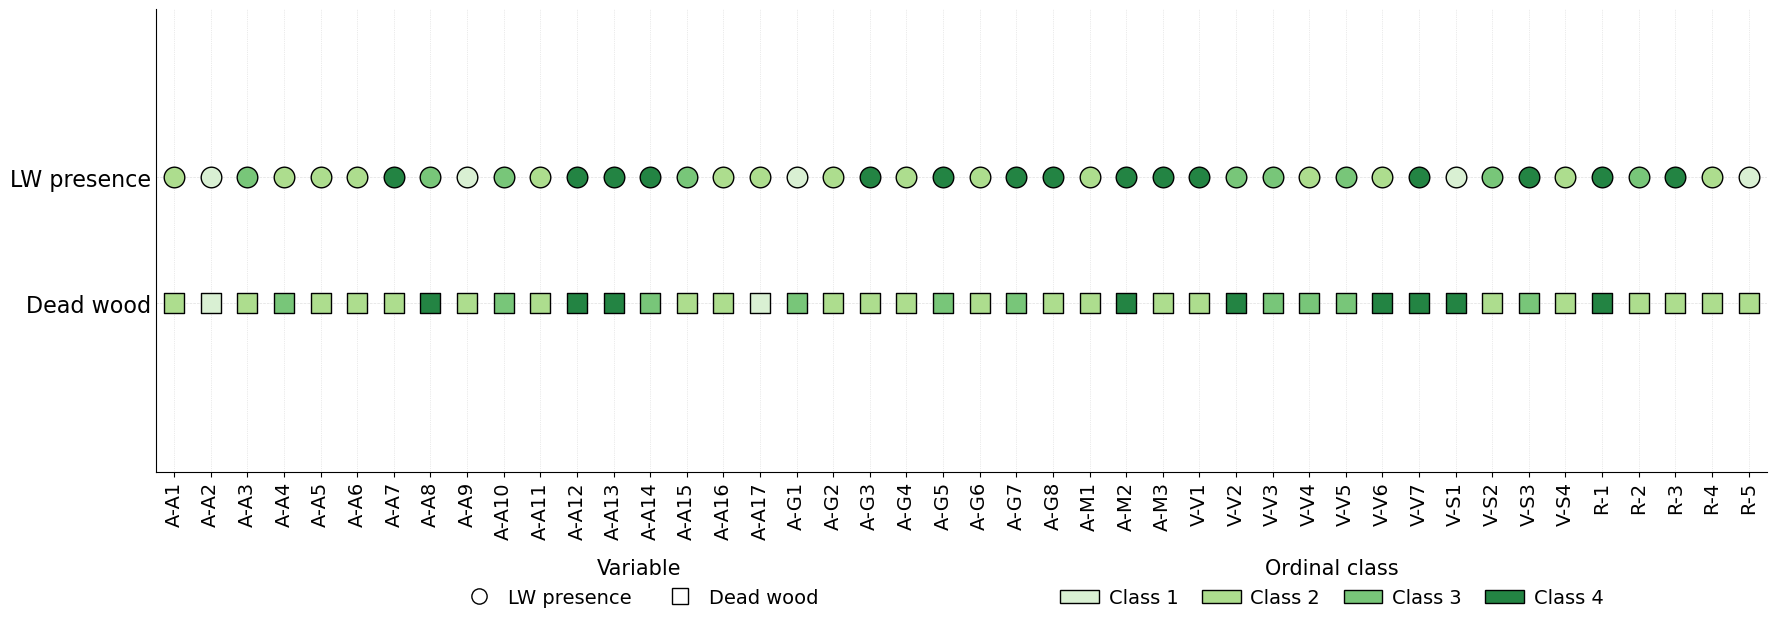

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\lw_deadwood_by_reach.png


In [32]:
# Cell A10 — Plot first version

output_path = DATA_DIR / "lw_deadwood_by_reach.png"

fig = plot_reach_ordinal_variables(
    df_reach=df_rf_reach,
    reach_column="Reach",
    variable_columns=ORDINAL_VARIABLES,
    class_colors=CLASS_COLORS,
    variable_markers=VARIABLE_MARKERS,
    variable_labels=VARIABLE_LABELS,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)

In [33]:
# Cell B1 — Prepare ordered bank-level dataset

def prepare_bank_level_ordinal_data(
    df,
    reach_column="Reach",
    bank_column="Bank",
    order_column="Id_Reach",
    variable_columns=None,
):
    """
    Prepare bank-level ordinal data ordered by reach and bank.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    reach_column : str
        Reach code column.
    bank_column : str
        Bank column.
    order_column : str
        Numeric order column.
    variable_columns : list of str or None
        Ordinal variables to keep.

    Returns
    -------
    pandas.DataFrame
        Ordered dataframe ready for plotting.
    """
    if variable_columns is None:
        variable_columns = ["LW_Presence", "Dead_Wood"]

    df_plot = df.copy()

    required_columns = [reach_column, bank_column, order_column] + variable_columns
    missing_columns = [col for col in required_columns if col not in df_plot.columns]

    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    df_plot[order_column] = pd.to_numeric(df_plot[order_column], errors="coerce")

    for column in variable_columns:
        df_plot[column] = pd.to_numeric(df_plot[column], errors="coerce")

    if df_plot[order_column].isna().any():
        raise ValueError(f"Some values in {order_column} could not be converted.")

    bank_order_map = {
        "Left": 0,
        "Left ": 0,
        "Right": 1,
        "Right ": 1,
    }

    df_plot["Bank_Order"] = (
        df_plot[bank_column]
        .astype(str)
        .str.strip()
        .map(bank_order_map)
    )

    if df_plot["Bank_Order"].isna().any():
        raise ValueError("Unexpected bank labels found in the Bank column.")

    df_plot = df_plot.sort_values(
        by=[order_column, "Bank_Order"]
    ).reset_index(drop=True)

    df_plot["Plot_Label"] = (
        df_plot[reach_column].astype(str)
        + "-"
        + df_plot[bank_column].astype(str).str.strip()
    )

    return df_plot

In [34]:
# Cell B2 — Create ordered plotting dataframe

ORDINAL_VARIABLES = ["LW_Presence", "Dead_Wood"]

df_rf_plot = prepare_bank_level_ordinal_data(
    df=df_rf,
    reach_column="Reach",
    bank_column="Bank",
    order_column="Id_Reach",
    variable_columns=ORDINAL_VARIABLES,
)

display(df_rf_plot.head(20))
display(df_rf_plot.tail(20))

,Id_RipUnit,Id_Reach,Basin,Sub_Basin,Reach,Bank,RipUnit,Lentgh (m),LW_Presence,Dead_Wood,...,Width_Mean,Basal_Area (m2/ha),P50_Height,Height_IQR,Invasive_Ab,StructuralIndex,ValleyConfinIndex,ELE (EffectLatExp),Bank_Order,Plot_Label
0,1,1,Arve,Arve,A-A1,Left,A-A1-Left,6062,2,2,...,12.4,26.88376,17.60,9.90,2,0.633698,12.573561,6.286780,0,A-A1-Left
1,2,1,Arve,Arve,A-A1,Right,A-A1-Right,6062,2,3,...,12.4,45.93959,23.10,12.70,1,0.734203,12.086567,12.086567,1,A-A1-Right
2,3,2,Arve,Arve,A-A2,Left,A-A2-Left,5575,1,1,...,14.1,9.68388,16.10,5.43,1,0.787197,16.384272,4.096068,0,A-A2-Left
3,4,2,Arve,Arve,A-A2,Right,A-A2-Right,5575,1,1,...,14.1,7.24400,16.35,5.10,1,0.850755,17.158012,4.289503,1,A-A2-Right
4,5,3,Arve,Arve,A-A3,Left,A-A3-Left,5530,3,2,...,38.2,25.69806,16.30,5.60,1,0.676002,2.652461,1.989345,0,A-A3-Left
5,6,3,Arve,Arve,A-A3,Right,A-A3-Right,5530,3,3,...,38.2,22.72654,19.40,7.60,1,0.642811,2.751326,2.751326,1,A-A3-Right
6,7,4,Arve,Arve,A-A4,Left,A-A4-Left,4885,2,2,...,24.3,42.95321,19.00,12.50,0,0.663570,3.767851,3.767851,0,A-A4-Left
7,8,4,Arve,Arve,A-A4,Right,A-A4-Right,4885,2,4,...,24.3,24.45142,23.40,11.30,1,0.725000,3.826187,3.826187,1,A-A4-Right
8,9,5,Arve,Arve,A-A5,Left,A-A5-Left,6304,2,2,...,17.4,26.67799,17.55,9.90,0,0.796635,9.919900,9.919900,0,A-A5-Left
9,10,5,Arve,Arve,A-A5,Right,A-A5-Right,6304,2,3,...,17.4,46.07861,16.00,10.15,0,0.776207,10.431502,10.431502,1,A-A5-Right


,Id_RipUnit,Id_Reach,Basin,Sub_Basin,Reach,Bank,RipUnit,Lentgh (m),LW_Presence,Dead_Wood,...,Width_Mean,Basal_Area (m2/ha),P50_Height,Height_IQR,Invasive_Ab,StructuralIndex,ValleyConfinIndex,ELE (EffectLatExp),Bank_Order,Plot_Label
68,69,35,Valserine,Valserine,V-V7,Left,V-V7-Left,3748,4,3,...,35.7,29.43611,22.75,7.75,2,0.589695,1.378795,1.378795,0,V-V7-Left
69,70,35,Valserine,Valserine,V-V7,Right,V-V7-Right,3748,4,4,...,35.7,24.90089,21.80,8.80,0,0.813889,1.389743,1.389743,1,V-V7-Right
70,71,36,Valserine,Semine,V-S1,Left,V-S1-Left,8486,1,4,...,11.2,35.74823,27.50,7.40,0,0.806920,4.387309,4.387309,0,V-S1-Left
71,72,36,Valserine,Semine,V-S1,Right,V-S1-Right,8486,1,4,...,11.2,24.35202,26.40,8.50,1,0.683939,4.387309,4.387309,1,V-S1-Right
72,73,37,Valserine,Semine,V-S2,Left,V-S2-Left,3852,3,1,...,11.5,18.14722,25.20,8.50,0,0.796063,5.789993,5.789993,0,V-S2-Left
73,74,37,Valserine,Semine,V-S2,Right,V-S2-Right,3852,3,3,...,11.5,32.92464,22.00,8.70,0,0.824533,5.501038,5.501038,1,V-S2-Right
74,75,38,Valserine,Semine,V-S3,Left,V-S3-Left,6198,4,2,...,22.2,30.68823,20.40,9.10,0,0.642429,2.648607,2.648607,0,V-S3-Left
75,76,38,Valserine,Semine,V-S3,Right,V-S3-Right,6198,4,4,...,22.2,56.91015,21.00,10.15,0,0.739281,2.648607,2.648607,1,V-S3-Right
76,77,39,Valserine,Semine,V-S4,Left,V-S4-Left,2966,2,2,...,26.4,36.68699,21.00,7.60,0,0.524230,1.643974,1.643974,0,V-S4-Left
77,78,39,Valserine,Semine,V-S4,Right,V-S4-Right,2966,2,3,...,26.4,37.73112,24.70,8.48,1,0.605155,1.653956,1.653956,1,V-S4-Right


In [35]:
# Cell B3 — Plot two ordinal variables across ordered bank units

def plot_bank_level_ordinal_profile(
    df_plot,
    x_label_column="Plot_Label",
    variable_columns=None,
    variable_labels=None,
    variable_colors=None,
    variable_markers=None,
    show_lines=False,
    line_width=0.8,
    marker_size=7,
    output_path=None,
):
    """
    Plot two ordinal variables across ordered bank-level units.

    Parameters
    ----------
    df_plot : pandas.DataFrame
        Ordered plotting dataframe.
    x_label_column : str
        Column used for x-axis labels.
    variable_columns : list of str or None
        Variables to plot.
    variable_labels : dict or None
        Display labels for variables.
    variable_colors : dict or None
        Line/marker colors by variable.
    variable_markers : dict or None
        Marker symbols by variable.
    show_lines : bool
        Whether to connect points with lines.
    line_width : float
        Width of lines if shown.
    marker_size : int or float
        Marker size.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    if variable_columns is None:
        variable_columns = ["LW_Presence", "Dead_Wood"]

    if variable_labels is None:
        variable_labels = {
            "LW_Presence": "LW presence",
            "Dead_Wood": "Dead wood",
        }

    if variable_colors is None:
        variable_colors = {
            "LW_Presence": "#1f77b4",
            "Dead_Wood": "#ff7f0e",
        }

    if variable_markers is None:
        variable_markers = {
            "LW_Presence": "o",
            "Dead_Wood": "s",
        }

    n_units = len(df_plot)
    fig_width = max(16, 0.28 * n_units)
    fig_height = 6.5

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    x_positions = list(range(n_units))

    for variable in variable_columns:
        y_values = df_plot[variable].values

        if show_lines:
            ax.plot(
                x_positions,
                y_values,
                color=variable_colors[variable],
                linewidth=line_width,
                marker=variable_markers[variable],
                markersize=marker_size,
                label=variable_labels[variable],
            )
        else:
            ax.scatter(
                x_positions,
                y_values,
                color=variable_colors[variable],
                marker=variable_markers[variable],
                s=marker_size ** 2,
                label=variable_labels[variable],
                zorder=3,
            )

    ax.set_xlim(-0.5, n_units - 0.5)
    ax.set_ylim(0.9, 4.1)
    ax.margins(x=0)

    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([1, 2, 3, 4], fontsize=14)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        df_plot[x_label_column],
        rotation=45,
        ha="right",
        fontsize=12,
    )

    ax.set_ylabel("Ordinal class", fontsize=16)
    ax.set_xlabel("", fontsize=14)

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=2,
        frameon=False,
        fontsize=14,
        handlelength=1.6,
        handletextpad=0.5,
        columnspacing=1.5,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.97,
        bottom=0.28,
    )

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

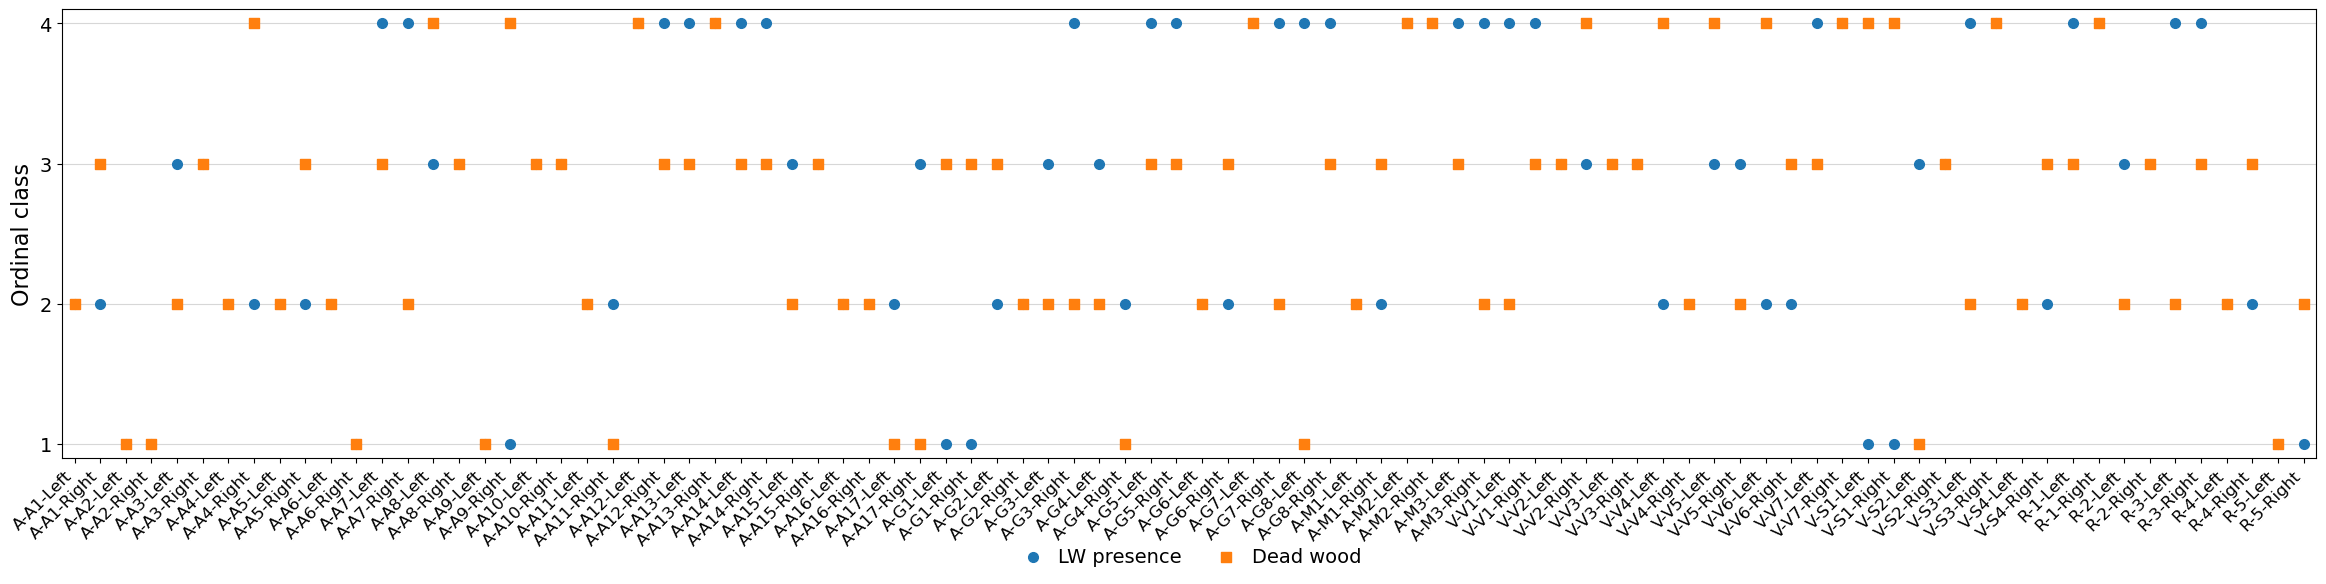

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\lw_deadwood_bank_level_markers_only.png


In [36]:
# Cell B4 — Plot without connecting lines

output_path = DATA_DIR / "lw_deadwood_bank_level_markers_only.png"

fig = plot_bank_level_ordinal_profile(
    df_plot=df_rf_plot,
    x_label_column="Plot_Label",
    variable_columns=ORDINAL_VARIABLES,
    variable_labels={
        "LW_Presence": "LW presence",
        "Dead_Wood": "Dead wood",
    },
    variable_colors={
        "LW_Presence": "#1f77b4",
        "Dead_Wood": "#ff7f0e",
    },
    variable_markers={
        "LW_Presence": "o",
        "Dead_Wood": "s",
    },
    show_lines=False,
    marker_size=7,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)

In [37]:
# Cell C1 — Helper function for round-half-up

import math


def round_half_up(value):
    """
    Round a number to the nearest integer, with .5 rounded upward.

    Examples
    --------
    1.4 -> 1
    1.5 -> 2
    2.5 -> 3
    3.49 -> 3
    """
    return int(math.floor(value + 0.5))

In [38]:
# Cell C2 — Build reach-level ordinal dataset

def build_reach_level_deadwood_lw(
    df,
    reach_column="Reach",
    order_column="Id_Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
):
    """
    Build a reach-level table for LW presence and Dead wood.

    Aggregation rules
    -----------------
    - LW_Presence: keep one value per reach (first value, assuming both
      banks have the same value).
    - Dead_Wood: calculate the mean across banks and round half up.

    Parameters
    ----------
    df : pandas.DataFrame
        Input bank-level dataframe.
    reach_column : str
        Reach identifier column.
    order_column : str
        Numeric column used to order reaches.
    lw_column : str
        LW presence column.
    deadwood_column : str
        Dead wood column.

    Returns
    -------
    pandas.DataFrame
        Reach-level ordered dataframe.
    """
    df_work = df.copy()

    required_columns = [
        reach_column,
        order_column,
        lw_column,
        deadwood_column,
    ]

    missing_columns = [
        column for column in required_columns
        if column not in df_work.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    df_work[order_column] = pd.to_numeric(
        df_work[order_column],
        errors="coerce",
    )
    df_work[lw_column] = pd.to_numeric(
        df_work[lw_column],
        errors="coerce",
    )
    df_work[deadwood_column] = pd.to_numeric(
        df_work[deadwood_column],
        errors="coerce",
    )

    if df_work[[order_column, lw_column, deadwood_column]].isna().any().any():
        raise ValueError(
            "Some values in Id_Reach, LW_Presence, or Dead_Wood "
            "could not be converted to numeric."
        )

    reach_level = (
        df_work
        .groupby(reach_column, as_index=False)
        .agg(
            {
                order_column: "min",
                lw_column: "first",
                deadwood_column: "mean",
            }
        )
        .sort_values(order_column)
        .reset_index(drop=True)
    )

    reach_level[deadwood_column] = reach_level[deadwood_column].apply(
        round_half_up
    )

    reach_level[lw_column] = reach_level[lw_column].astype(int)
    reach_level[deadwood_column] = reach_level[deadwood_column].astype(int)

    return reach_level

In [39]:
# Cell C3 — Create reach-level dataframe

df_rf_reach = build_reach_level_deadwood_lw(
    df=df_rf,
    reach_column="Reach",
    order_column="Id_Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
)

display(df_rf_reach.head(20))
display(df_rf_reach.tail(10))

,Reach,Id_Reach,LW_Presence,Dead_Wood
0,A-A1,1,2,3
1,A-A2,2,1,1
2,A-A3,3,3,3
3,A-A4,4,2,3
4,A-A5,5,2,3
5,A-A6,6,1,2
6,A-A7,7,4,3
7,A-A8,8,3,4
8,A-A9,9,1,3
9,A-A10,10,3,3


,Reach,Id_Reach,LW_Presence,Dead_Wood
34,V-V7,35,4,4
35,V-S1,36,1,4
36,V-S2,37,3,2
37,V-S3,38,4,3
38,V-S4,39,2,3
39,R-1,40,4,4
40,R-2,41,3,3
41,R-3,42,4,3
42,R-4,43,2,3
43,R-5,44,1,2


In [40]:
# Cell C4 — Check whether LW_Presence is identical across banks

lw_consistency = (
    df_rf.groupby("Reach")["LW_Presence"]
    .nunique()
    .reset_index(name="LW_Unique_Values")
)

inconsistent_lw = lw_consistency[lw_consistency["LW_Unique_Values"] > 1]

print("Number of reaches checked:", len(lw_consistency))
print("Reaches with inconsistent LW_Presence values:",
      len(inconsistent_lw))

display(inconsistent_lw)

Number of reaches checked: 44
Reaches with inconsistent LW_Presence values: 4


,Reach,LW_Unique_Values
8,A-A17,2
13,A-A6,2
19,A-G3,2
20,A-G4,2


In [41]:
# Cell C5 — Plot reach-level ordinal profile

def plot_reach_level_ordinal_profile(
    df_plot,
    x_label_column="Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
    show_lines=True,
    line_width=0.7,
    marker_size=7,
    output_path=None,
):
    """
    Plot LW presence and Dead wood across reaches.

    Parameters
    ----------
    df_plot : pandas.DataFrame
        Reach-level ordered dataframe.
    x_label_column : str
        Column used for x-axis labels.
    lw_column : str
        LW presence column.
    deadwood_column : str
        Dead wood column.
    show_lines : bool
        Whether to draw connecting lines.
    line_width : float
        Width of connecting lines.
    marker_size : int or float
        Marker size.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    n_reaches = len(df_plot)

    fig_width = max(16, 0.34 * n_reaches)
    fig_height = 6.2

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    x_positions = list(range(n_reaches))

    lw_values = df_plot[lw_column].values
    deadwood_values = df_plot[deadwood_column].values

    if show_lines:
        ax.plot(
            x_positions,
            lw_values,
            color="#1f77b4",
            linewidth=line_width,
            marker="o",
            markersize=marker_size,
            label="LW presence",
        )

        ax.plot(
            x_positions,
            deadwood_values,
            color="#ff7f0e",
            linewidth=line_width,
            marker="s",
            markersize=marker_size,
            label="Dead wood",
        )
    else:
        ax.scatter(
            x_positions,
            lw_values,
            color="#1f77b4",
            marker="o",
            s=marker_size ** 2,
            label="LW presence",
            zorder=3,
        )

        ax.scatter(
            x_positions,
            deadwood_values,
            color="#ff7f0e",
            marker="s",
            s=marker_size ** 2,
            label="Dead wood",
            zorder=3,
        )

    ax.set_xlim(-0.5, n_reaches - 0.5)
    ax.set_ylim(0.9, 4.1)
    ax.margins(x=0)

    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([1, 2, 3, 4], fontsize=14)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        df_plot[x_label_column],
        rotation=90,
        fontsize=13,
    )

    ax.set_ylabel("Ordinal class", fontsize=16)
    ax.set_xlabel("")

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=2,
        frameon=False,
        fontsize=14,
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.5,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.97,
        bottom=0.24,
    )

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

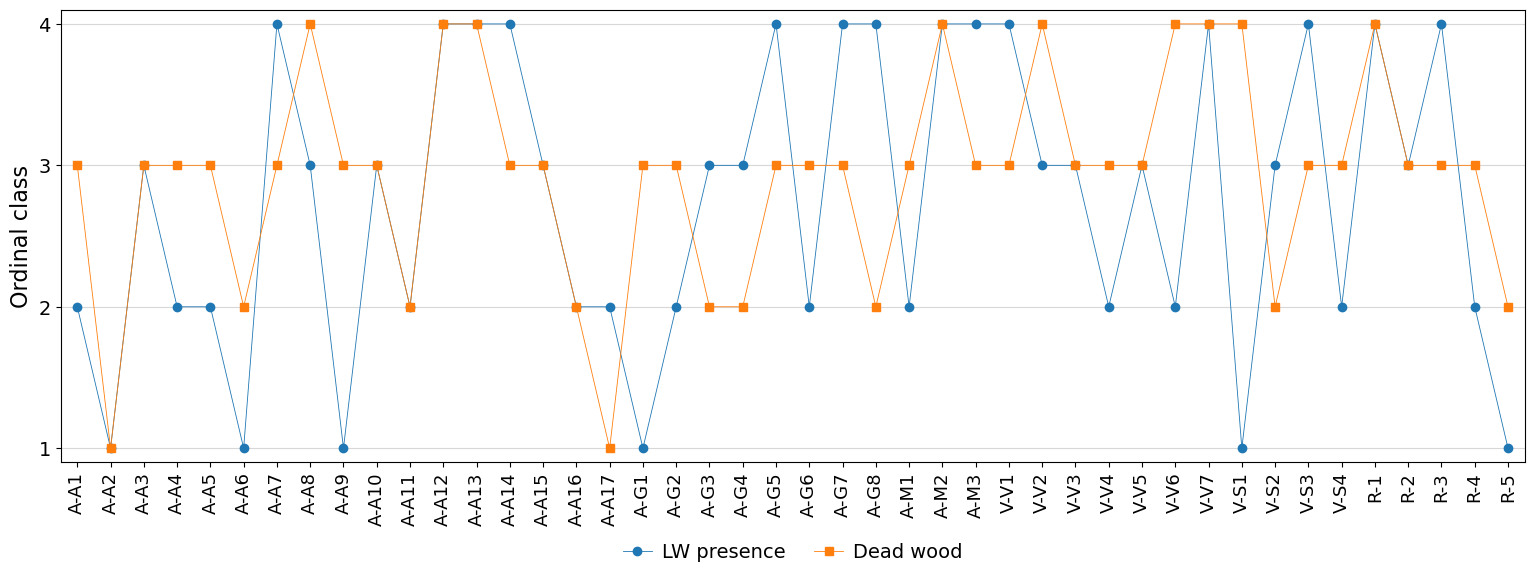

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\lw_deadwood_reach_level_thin_lines.png


In [42]:
# Cell C6 — Plot reach-level profile with very thin lines

output_path = DATA_DIR / "lw_deadwood_reach_level_thin_lines.png"

fig = plot_reach_level_ordinal_profile(
    df_plot=df_rf_reach,
    x_label_column="Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
    show_lines=True,
    line_width=0.6,
    marker_size=6,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)

In [47]:
# Cell C5 — Plot reach-level ordinal profile

def plot_reach_level_ordinal_profile(
    df_plot,
    x_label_column="Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
    show_lines=True,
    line_width=0.8,
    line_alpha=0.35,
    lw_marker_size=13,
    deadwood_marker_size=8,
    output_path=None,
):
    """
    Plot LW presence and Dead wood across reaches.

    Lines are transparent, while markers remain fully opaque.
    LW markers are larger so they remain visible behind Dead wood
    markers when both overlap.

    Parameters
    ----------
    df_plot : pandas.DataFrame
        Reach-level ordered dataframe.
    x_label_column : str
        Column used for x-axis labels.
    lw_column : str
        LW presence column.
    deadwood_column : str
        Dead wood column.
    show_lines : bool
        Whether to draw connecting lines.
    line_width : float
        Width of connecting lines.
    line_alpha : float
        Transparency of connecting lines only.
    lw_marker_size : int or float
        Marker size for LW presence.
    deadwood_marker_size : int or float
        Marker size for Dead wood.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    n_reaches = len(df_plot)

    fig_width = max(16, 0.34 * n_reaches)
    fig_height = 6.2

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    x_positions = list(range(n_reaches))

    lw_values = df_plot[lw_column].values
    deadwood_values = df_plot[deadwood_column].values

    if show_lines:
        # Transparent lines only
        ax.plot(
            x_positions,
            lw_values,
            color="#1f77b4",
            linewidth=line_width,
            alpha=line_alpha,
            zorder=1,
        )

        ax.plot(
            x_positions,
            deadwood_values,
            color="#ff7f0e",
            linewidth=line_width,
            alpha=line_alpha,
            zorder=1,
        )

    # Larger LW markers behind
    ax.scatter(
        x_positions,
        lw_values,
        color="#1f77b4",
        marker="o",
        s=lw_marker_size ** 2,
        edgecolor="black",
        linewidth=0.7,
        alpha=1.0,
        label="LW presence",
        zorder=2,
    )

    # Smaller Dead wood markers on top
    ax.scatter(
        x_positions,
        deadwood_values,
        color="#ff7f0e",
        marker="s",
        s=deadwood_marker_size ** 2,
        edgecolor="black",
        linewidth=0.7,
        alpha=1.0,
        label="Dead wood",
        zorder=3,
    )

    ax.set_xlim(-0.5, n_reaches - 0.5)
    ax.set_ylim(0.9, 4.1)
    ax.margins(x=0)

    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([1, 2, 3, 4], fontsize=14)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        df_plot[x_label_column],
        rotation=90,
        fontsize=13,
    )

    ax.set_ylabel("Ordinal class", fontsize=16)
    ax.set_xlabel("")

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=2,
        frameon=False,
        fontsize=14,
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.5,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.97,
        bottom=0.24,
    )

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

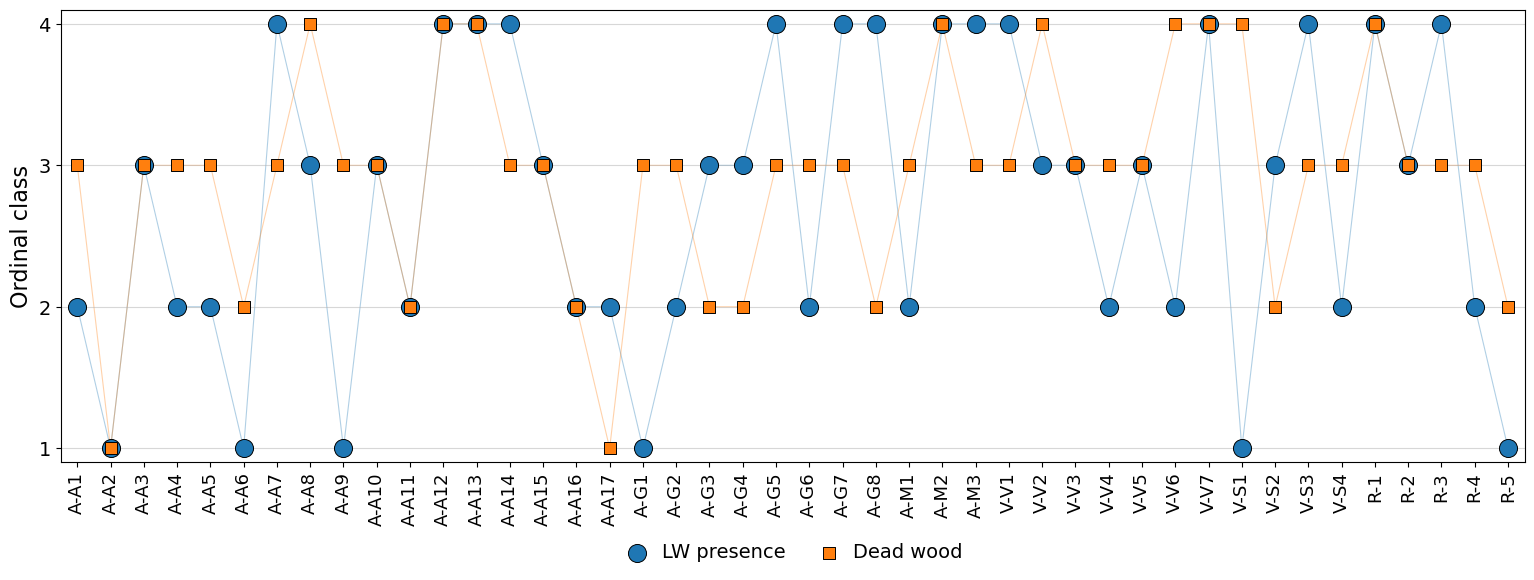

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\lw_deadwood_reach_level_thin_lines.png


In [48]:
# Cell C6 — Plot reach-level profile with larger LW markers

output_path = DATA_DIR / "lw_deadwood_reach_level_thin_lines.png"

fig = plot_reach_level_ordinal_profile(
    df_plot=df_rf_reach,
    x_label_column="Reach",
    lw_column="LW_Presence",
    deadwood_column="Dead_Wood",
    show_lines=True,
    line_width=0.8,
    line_alpha=0.35,
    lw_marker_size=13,
    deadwood_marker_size=8,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)

In [55]:
# Cell C5 — Plot reach-level ordinal profile with FLW/CLW styling

def plot_reach_level_ordinal_profile(
    df_plot,
    x_label_column="Reach",
    flw_column="LW_Presence",
    clw_column="Dead_Wood",
    show_lines=True,
    line_width=0.8,
    line_alpha=0.35,
    flw_marker_size=13,
    clw_marker_size=8,
    output_path=None,
):
    """
    Plot FLW and CLW across reaches.

    Assumed mapping
    ---------------
    - LW_Presence -> Floodplain Large Wood (FLW) 
    - Dead_Wood   -> In-channel Large Wood (CLW) 

    Lines are transparent, while markers remain fully opaque.
    FLW markers are larger so they remain visible behind CLW
    markers when both overlap.

    Parameters
    ----------
    df_plot : pandas.DataFrame
        Reach-level ordered dataframe.
    x_label_column : str
        Column used for x-axis labels.
    flw_column : str
        Column representing FLW.
    clw_column : str
        Column representing CLW.
    show_lines : bool
        Whether to draw connecting lines.
    line_width : float
        Width of connecting lines.
    line_alpha : float
        Transparency of connecting lines only.
    flw_marker_size : int or float
        Marker size for FLW.
    clw_marker_size : int or float
        Marker size for CLW.
    output_path : pathlib.Path or None
        Optional output path.

    Returns
    -------
    matplotlib.figure.Figure
        Generated figure.
    """
    n_reaches = len(df_plot)

    fig_width = max(16, 0.34 * n_reaches)
    fig_height = 6.2

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    x_positions = list(range(n_reaches))

    flw_values = df_plot[flw_column].values
    clw_values = df_plot[clw_column].values

    # Paper-consistent colors
    flw_color = "#d95f02"   # orange-brown family, similar to FLW palette
    clw_color = "#1f78b4"   # blue family, similar to CLW palette

    if show_lines:
        # Transparent lines only
        ax.plot(
            x_positions,
            flw_values,
            color=flw_color,
            linewidth=line_width,
            alpha=line_alpha,
            zorder=1,
        )

        ax.plot(
            x_positions,
            clw_values,
            color=clw_color,
            linewidth=line_width,
            alpha=line_alpha,
            zorder=1,
        )

    # Larger FLW markers behind
    ax.scatter(
        x_positions,
        flw_values,
        color=flw_color,
        marker="o",
        s=flw_marker_size ** 2,
        edgecolor="black",
        linewidth=0.7,
        alpha=1.0,
        label="Floodplain Large Wood (FLW)",
        zorder=2,
    )

    # Smaller CLW markers on top
    ax.scatter(
        x_positions,
        clw_values,
        color=clw_color,
        marker="s",
        s=clw_marker_size ** 2,
        edgecolor="black",
        linewidth=0.7,
        alpha=1.0,
        label="In-channel Large Wood (CLW)",
        zorder=3,
    )

    ax.set_xlim(-0.5, n_reaches - 0.5)
    ax.set_ylim(0.9, 4.1)
    ax.margins(x=0)

    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([1, 2, 3, 4], fontsize=14)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        df_plot[x_label_column],
        rotation=90,
        fontsize=13,
    )

    ax.set_ylabel("Ordinal class", fontsize=16)
    ax.set_xlabel("")

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.5)
    ax.grid(axis="x", visible=False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=2,
        frameon=False,
        fontsize=14,
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.5,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.995,
        top=0.97,
        bottom=0.24,
    )

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    return fig

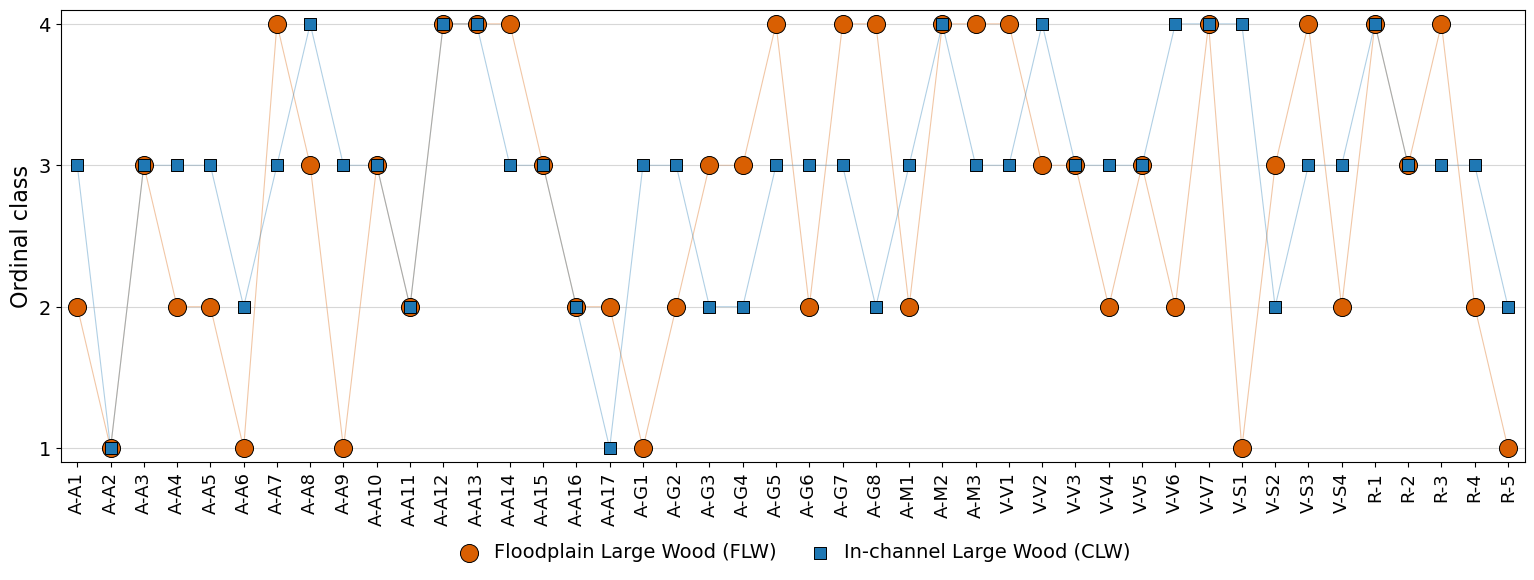

Saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\flw_clw_reach_level_profile.png


In [56]:
# Cell C6 — Plot reach-level profile with FLW/CLW labels

output_path = DATA_DIR / "flw_clw_reach_level_profile.png"

fig = plot_reach_level_ordinal_profile(
    df_plot=df_rf_reach,
    x_label_column="Reach",
    flw_column="LW_Presence",
    clw_column="Dead_Wood",
    show_lines=True,
    line_width=0.8,
    line_alpha=0.35,
    flw_marker_size=13,
    clw_marker_size=8,
    output_path=output_path,
)

plt.show()

print("Saved:", output_path)